# EN3150 Assignment 03: Resource-Constrained Image Classification

This notebook compares standard and lightweight convolutional neural
networks for EuroSAT RGB land-cover classification.

- **Input:** A 64 × 64 RGB satellite image.
- **Target:** One of 10 land-cover classes.
- **Custom models:** A standard CNN and a depthwise-separable CNN.
- **Pretrained models:** MobileNetV2 and ShuffleNetV2.
- **Evaluation:** Classification performance, model size and computational cost.

## 1. Environment verification

We first check the active Python environment, package versions and
PyTorch GPU availability. This establishes the hardware and software
used for the experiments.

I now use the shared `cnn_assignment` package for preprocessing, models,
saved-result plots and validation. I keep the original cell outputs as my
experiment record. The revised cells reuse saved splits and normalization
and read completed histories. I start new training only from the terminal.
The first code cell finds the project and adds `src/` to this kernel's import
path. No terminal `PYTHONPATH` setting or package installation is needed.

After restarting the kernel, run the first code cell, then any saved-history,
learning-curve, comparison or saved-checkpoint validation cell in section 7.
Those cells load their inputs from disk; the training setup and data exploration
sections are optional for this workflow. Section 7.20 restores the saved splits
and normalization for preprocessing previews. For a full notebook run, execute
the cells in order. Every plot/validation invocation writes a fresh report folder
under `outputs/reports/`, so rerunning analysis preserves earlier reports.
New training remains an explicit terminal command described in README.md.


In [1]:
import sys
from pathlib import Path
import platform
from importlib.metadata import version, PackageNotFoundError
from tempfile import mkdtemp

# Run this setup cell once after a kernel restart. Works from the project
# root or notebooks/ (and deeper subfolders), without a terminal PYTHONPATH.
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "pyproject.toml").is_file() and (candidate / "src/cnn_assignment").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Open this notebook with the kernel working in the project root or notebooks/.")
source_dir = str(PROJECT_ROOT / "src")
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image as DisplayImage
import torch
import torchvision
from cnn_assignment.utils import load_config, resolve_path

RUN_DIR = PROJECT_ROOT / "outputs/custom_cnn"
saved_config = load_config(RUN_DIR / "model_a_adam_lr0.001/config.json")
RAW_DATA_DIR = PROJECT_ROOT / "data/raw"
ARCHIVE_PATH = RAW_DATA_DIR / "eurosat/EuroSAT.zip"
DATA_ROOT = resolve_path(PROJECT_ROOT, saved_config.get("data_root", "data/raw/eurosat/2750"))
SPLIT_DIR = resolve_path(PROJECT_ROOT, saved_config.get("split_dir", "data/splits"))
CLASS_NAMES = saved_config["class_names"]
SEED = saved_config["seed"]


def new_notebook_report(name):
    # A fresh folder per analysis invocation makes reruns safe and retains reports.
    reports = PROJECT_ROOT / "outputs/reports"
    reports.mkdir(parents=True, exist_ok=True)
    return Path(mkdtemp(prefix=f"notebook_{name}_", dir=reports))


def load_saved_split(split_name):
    from cnn_assignment.data import load_split
    frame = load_split(SPLIT_DIR, split_name, CLASS_NAMES)
    frame["path"] = frame["relative_path"].map(lambda relative: str(DATA_ROOT / relative))
    return frame

print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("Operating system:", platform.platform())

print("\nPackage versions:")
for package in [
    "torch",
    "torchvision",
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "Pillow",
]:
    try:
        print(f"  {package}: {version(package)}")
    except PackageNotFoundError:
        print(f"  {package}: not installed (optional environment check)")

print("\nGPU information:")
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

if device.type == "cuda":
    properties = torch.cuda.get_device_properties(0)
    print("GPU:", properties.name)
    print(f"Total GPU memory: {properties.total_memory / 1024**3:.2f} GiB")

# Verify that a small tensor operation works on the selected device.
x = torch.ones((2, 3), device=device)
print("\nDevice computation check:", (x * 2).sum().item())


Python executable: c:\Users\hrana\anaconda3\envs\ml_env_fixed\python.exe
Python version: 3.11.14
Operating system: Windows-10-10.0.26200-SP0

Package versions:
  torch: 2.5.1
  torchvision: 0.20.1
  numpy: 1.26.4
  pandas: 2.3.3
  scikit-learn: 1.8.0
  matplotlib: 3.10.9
  Pillow: 12.3.0

GPU information:
PyTorch CUDA build: 11.8
CUDA available: True
Selected device: cuda
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design
Total GPU memory: 4.00 GiB

Device computation check: 12.0


## 2. Dataset location

I keep the original EuroSAT images in `data/raw/eurosat/2750`.
I use paths relative to the project folder so the notebook can run
on another computer without changing a personal file path.

In [2]:
# Project paths are initialized by the first setup cell.
print("Project folder:", PROJECT_ROOT)
print("Image folder:", DATA_ROOT)
print("Saved splits:", SPLIT_DIR)
print("Saved experiments:", RUN_DIR)


Project folder: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN
Image folder: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\data\raw\eurosat\2750
Saved splits: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\data\splits
Saved experiments: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\custom_cnn


### 2.1 Load the dataset

I downloaded the EuroSAT RGB archive through my browser.
I check its checksum before extracting it to confirm the download is complete.

I then load the original images without resizing or augmentation.

In [3]:
import hashlib
from zipfile import ZipFile
from torchvision.datasets import EuroSAT

if not ARCHIVE_PATH.is_file():
    raise FileNotFoundError(
        f"I need to place EuroSAT.zip here:\n{ARCHIVE_PATH}"
    )

# I check the archive against the checksum used by torchvision.
expected_md5 = "c8fa014336c82ac7804f0398fcb19387"

checksum = hashlib.md5()
with ARCHIVE_PATH.open("rb") as file:
    for chunk in iter(lambda: file.read(1024 * 1024), b""):
        checksum.update(chunk)

if checksum.hexdigest() != expected_md5:
    raise ValueError("The checksum does not match. Download the archive again.")

print("Archive checksum verified.")

# I extract the images if the dataset folder is not already present.
if not DATA_ROOT.is_dir():
    with ZipFile(ARCHIVE_PATH) as archive:
        archive.extractall(ARCHIVE_PATH.parent)
    print("Dataset extracted.")

# I load the images without applying any transforms.
dataset = EuroSAT(
    root=str(RAW_DATA_DIR),
    download=False,
    transform=None,
)

CLASS_NAMES = dataset.classes

print("\nTotal images:", len(dataset))
print("Number of classes:", len(CLASS_NAMES))

print("\nClass labels:")
for class_name, label in dataset.class_to_idx.items():
    print(f"  {label}: {class_name}")

# I check the size, colour mode and label of one image.
image, label = dataset[0]

print("\nFirst image:")
print("Size (width, height):", image.size)
print("Colour mode:", image.mode)
print("Label:", label)
print("Class:", CLASS_NAMES[label])

Archive checksum verified.

Total images: 27000
Number of classes: 10

Class labels:
  0: AnnualCrop
  1: Forest
  2: HerbaceousVegetation
  3: Highway
  4: Industrial
  5: Pasture
  6: PermanentCrop
  7: Residential
  8: River
  9: SeaLake

First image:
Size (width, height): (64, 64)
Colour mode: RGB
Label: 0
Class: AnnualCrop


## 3. Data exploration

### 3.1 Class distribution

I count the images in each class to check whether the dataset is balanced.
I also calculate each class's percentage of the total dataset.



,class_name,image_count,percentage
0,AnnualCrop,3000,11.11
1,Forest,3000,11.11
2,HerbaceousVegetation,3000,11.11
3,Highway,2500,9.26
4,Industrial,2500,9.26
5,Pasture,2000,7.41
6,PermanentCrop,2500,9.26
7,Residential,3000,11.11
8,River,2500,9.26
9,SeaLake,3000,11.11


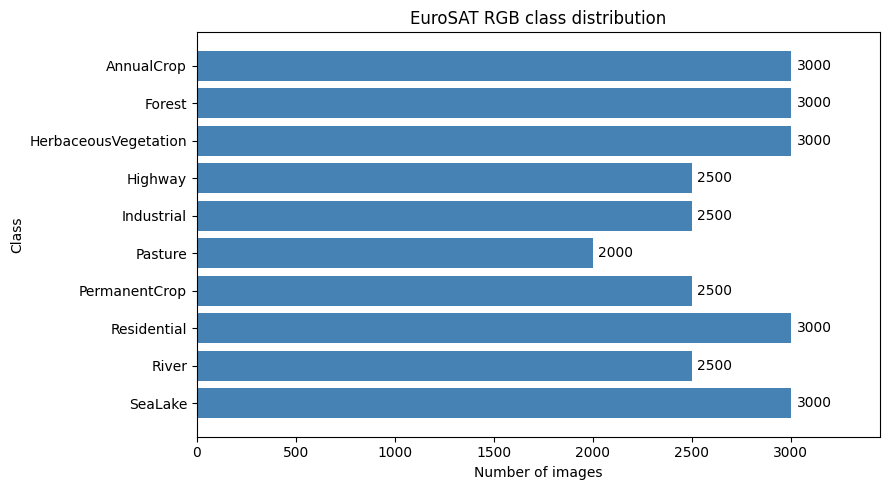

Largest class: 3,000 images
Smallest class: 2,000 images
Largest-to-smallest ratio: 1.50


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# I create one row for each image and its class label.
image_df = pd.DataFrame(dataset.samples, columns=["path", "label"])
image_df["class_name"] = image_df["label"].map(
    dict(enumerate(CLASS_NAMES))
)

# I count the images in each class.
class_counts = (
    image_df.groupby("class_name")
    .size()
    .reindex(CLASS_NAMES)
    .rename("image_count")
    .reset_index()
)

class_counts["percentage"] = (
    100 * class_counts["image_count"] / len(image_df)
).round(2)

display(class_counts)

# I plot the counts to compare the classes.
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    class_counts["class_name"],
    class_counts["image_count"],
    color="steelblue",
)

ax.bar_label(bars, padding=4)
ax.set_xlabel("Number of images")
ax.set_ylabel("Class")
ax.set_title("EuroSAT RGB class distribution")
ax.set_xlim(0, class_counts["image_count"].max() * 1.15)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

largest = class_counts["image_count"].max()
smallest = class_counts["image_count"].min()

print(f"Largest class: {largest:,} images")
print(f"Smallest class: {smallest:,} images")
print(f"Largest-to-smallest ratio: {largest / smallest:.2f}")

The class sizes range from 2,000 to 3,000 images. Pasture is the smallest
class, and the largest-to-smallest ratio is 1.5.

I use a stratified split to keep similar class proportions in the training,
validation and test sets. I start without class weighting and later check
per-class precision and recall to see whether smaller classes perform worse.

### 3.2 Sample images

I display three images from each class to inspect their colours, textures
and shapes. I use a fixed random seed so the same examples appear when
I rerun this cell.

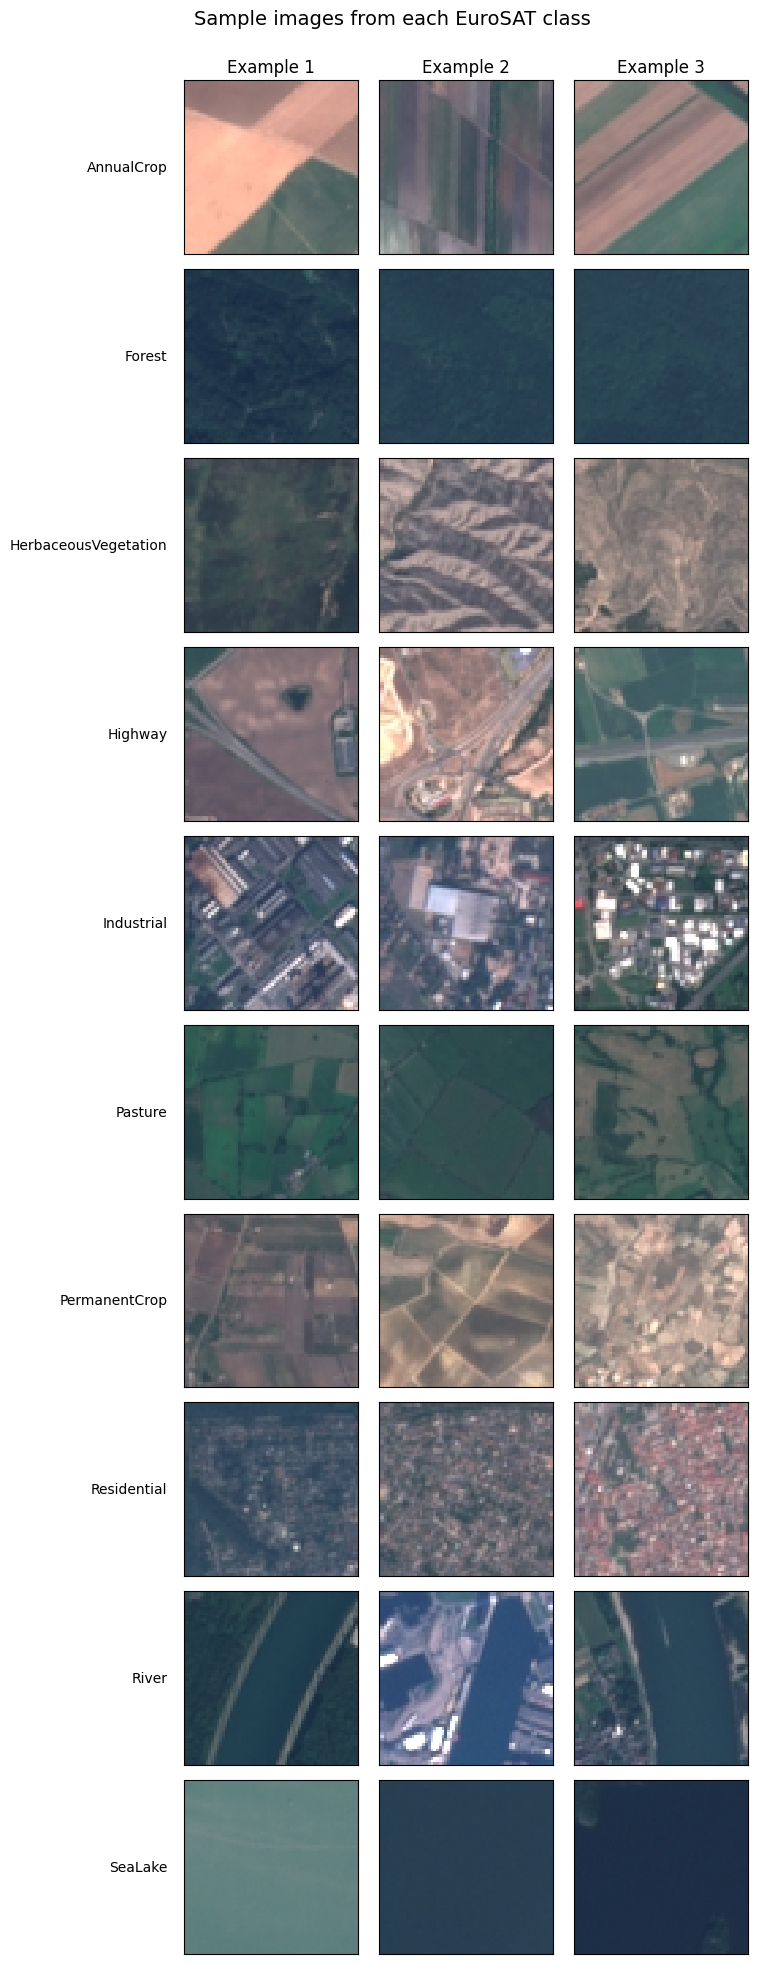

In [5]:
from PIL import Image

# I use a fixed seed to select the same examples each time.
SEED = 42
rng = np.random.default_rng(SEED)
samples_per_class = 3

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    samples_per_class,
    figsize=(8, 20),
)

for label, class_name in enumerate(CLASS_NAMES):
    class_indices = image_df.index[
        image_df["label"] == label
    ].to_numpy()

    selected_indices = rng.choice(
        class_indices,
        size=samples_per_class,
        replace=False,
    )

    for column, index in enumerate(selected_indices):
        image_path = image_df.loc[index, "path"]

        with Image.open(image_path) as image:
            axes[label, column].imshow(image, interpolation="nearest")

        axes[label, column].set_xticks([])
        axes[label, column].set_yticks([])

        if column == 0:
            axes[label, column].set_ylabel(
                class_name,
                rotation=0,
                ha="right",
                va="center",
                labelpad=12,
            )

        if label == 0:
            axes[label, column].set_title(f"Example {column + 1}")

fig.suptitle("Sample images from each EuroSAT class", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### 3.3 Image quality checks

I check that every image can be opened and fully read.
I also check the original image dimensions and colour modes.

This helps me find damaged files or unexpected image formats before
splitting the dataset.

In [6]:
from tqdm.auto import tqdm

image_checks = []

# I read every image and record its original size and colour mode.
for image_path in tqdm(image_df["path"], desc="Checking images"):
    record = {
        "path": image_path,
        "width": None,
        "height": None,
        "mode": None,
        "error": None,
    }

    try:
        with Image.open(image_path) as image:
            image.load()
            record["width"], record["height"] = image.size
            record["mode"] = image.mode

    except (OSError, ValueError) as error:
        record["error"] = str(error)

    image_checks.append(record)

quality_df = pd.DataFrame(image_checks)
valid_images = quality_df[quality_df["error"].isna()]
unreadable_images = quality_df[quality_df["error"].notna()]

print("Images checked:", len(quality_df))
print("Readable images:", len(valid_images))
print("Unreadable images:", len(unreadable_images))

print("\nImage sizes and colour modes:")
display(
    valid_images.groupby(["width", "height", "mode"])
    .size()
    .reset_index(name="image_count")
)

unexpected_images = valid_images[
    (valid_images["width"] != 64)
    | (valid_images["height"] != 64)
    | (valid_images["mode"] != "RGB")
]

print("Images with unexpected size or colour mode:", len(unexpected_images))

if not unreadable_images.empty:
    display(unreadable_images.head(10))

if not unexpected_images.empty:
    display(unexpected_images.head(10))

Checking images:   0%|          | 0/27000 [00:00<?, ?it/s]

Images checked: 27000
Readable images: 27000
Unreadable images: 0

Image sizes and colour modes:


,width,height,mode,image_count
0,64,64,RGB,27000


Images with unexpected size or colour mode: 0


All 27,000 images are readable and have a resolution of 64 × 64 pixels
with three RGB channels. I found no unreadable images or unexpected formats,
so no resizing is needed to meet the assignment's resolution limit.

From the displayed examples, I find some classes easier to recognise than
others. HerbaceousVegetation is less clear to me. I will later use the
confusion matrix to check which classes are difficult for the models.

### 3.4 Exact duplicate checks

I compare image pixels to find exact duplicates, even if their filenames
are different. I also check whether identical images have different labels.

This check finds identical images, but it does not detect similar scenes
or nearby geographic locations.

In [7]:
import hashlib

# I check that all images passed the earlier quality checks.
assert unreadable_images.empty, "Unreadable images need to be checked first."
assert unexpected_images.empty, "Unexpected image formats need to be checked first."

pixel_hashes = []

# I hash the original RGB pixels without changing the images.
for image_path in tqdm(image_df["path"], desc="Checking duplicates"):
    with Image.open(image_path) as image:
        pixel_hash = hashlib.sha256(image.tobytes()).hexdigest()
        pixel_hashes.append(pixel_hash)

image_df["pixel_hash"] = pixel_hashes

# I include every image belonging to a duplicate group.
duplicate_images = image_df[
    image_df.duplicated("pixel_hash", keep=False)
].copy()

duplicate_groups = duplicate_images["pixel_hash"].nunique()
extra_copies = len(image_df) - image_df["pixel_hash"].nunique()

# I check whether any identical images have different class labels.
labels_per_hash = image_df.groupby("pixel_hash")["label"].nunique()
conflicting_hashes = labels_per_hash[labels_per_hash > 1].index

print("Unique images:", image_df["pixel_hash"].nunique())
print("Duplicate groups:", duplicate_groups)
print("Images in duplicate groups:", len(duplicate_images))
print("Extra duplicate copies:", extra_copies)
print("Groups with conflicting labels:", len(conflicting_hashes))

if not duplicate_images.empty:
    display(
        duplicate_images.sort_values("pixel_hash")[
            ["path", "class_name", "pixel_hash"]
        ].head(20)
    )

Checking duplicates:   0%|          | 0/27000 [00:00<?, ?it/s]

Unique images: 27000
Duplicate groups: 0
Images in duplicate groups: 0
Extra duplicate copies: 0
Groups with conflicting labels: 0


I found 27,000 unique images with no exact duplicates or conflicting labels.
I keep all images for the dataset split.

## 4. Dataset splitting

I originally split the dataset into 70% training, 15% validation and 15% test.
I used stratification and seed 42 to preserve class proportions.

I now reuse the saved image lists and check their integrity through the shared
package. I keep the original label mapping and CSVs unchanged. I use validation
results for tuning and keep the test images for explicit final evaluation.


In [8]:
from cnn_assignment.data import check_splits

# I reuse the exact saved splits and class order from the setup cell.
split_summary = check_splits(SPLIT_DIR, CLASS_NAMES)
train_df = load_saved_split("train")
val_df = load_saved_split("validation")
test_df = load_saved_split("test")
split_counts = pd.DataFrame({
    "train": train_df.groupby("class_name").size(),
    "validation": val_df.groupby("class_name").size(),
    "test": test_df.groupby("class_name").size(),
}).reindex(CLASS_NAMES)
display(split_counts)
print(split_summary["sizes"])
print("I reused the saved split files without writing them.")


,train,validation,test
class_name,,,
AnnualCrop,2100,450,450
Forest,2100,450,450
HerbaceousVegetation,2100,450,450
Highway,1750,375,375
Industrial,1750,375,375
Pasture,1400,300,300
PermanentCrop,1750,375,375
Residential,2100,450,450
River,1750,375,375


{'train': 18900, 'validation': 4050, 'test': 4050}
I reused the saved split files without writing them.


The split contains 18,900 training images, 4,050 validation images and
4,050 test images, with no overlap. Each class follows the required
70/15/15 proportions.

I keep the original class distribution because the imbalance is mild.
I start with ordinary cross-entropy loss and check per-class results
during evaluation. If balancing is needed, I apply it only to the
training set.

## 5. Image preprocessing

### 5.1 Training-set mean and standard deviation

I originally scaled pixel values from 0–255 to 0–1 and calculated the mean and
population standard deviation for each RGB channel using only training images.
I now reload those exact values from my saved config instead of recalculating
them. I use them to normalize inputs to the custom CNNs.


In [9]:
train_df = load_saved_split("train")
# I restore the exact training statistics from my saved configuration.
train_mean = np.array(saved_config["normalization_mean"])
train_std = np.array(saved_config["normalization_std"])
normalization_stats = pd.DataFrame({
    "channel": ["Red", "Green", "Blue"], "mean": train_mean, "std": train_std,
})
display(normalization_stats.round(6))
print("Training images used originally:", len(train_df))
print("Pixels per channel:", len(train_df) * 64 * 64)


,channel,mean,std
0,Red,0.343901,0.202425
1,Green,0.379954,0.136683
2,Blue,0.407549,0.115408


Training images used originally: 18900
Pixels per channel: 77414400


### 5.2 Preprocessing and training augmentation

I keep the images at their original resolution of 64 × 64 pixels.

For training, I randomly flip images and rotate them by multiples of
90 degrees. These changes preserve the land-cover label while varying
the image orientation.

I convert images to tensors and normalize each channel using the
training-set mean and standard deviation. For validation and testing,
I apply only tensor conversion and normalization.

In [10]:
import random
from torchvision import transforms
from cnn_assignment.transforms import RandomQuarterTurn, make_augmentation, make_transform

train_df = load_saved_split("train")
train_mean = np.array(saved_config["normalization_mean"])
train_std = np.array(saved_config["normalization_std"])

# I use the same shared transforms as terminal training and evaluation.
train_augmentation = make_augmentation()
normalize = transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
train_transform = make_transform(saved_config, training=True)
eval_transform = make_transform(saved_config)

# I check preprocessing on a training image.
with Image.open(train_df.iloc[0]["path"]) as image:
    original_image = image.convert("RGB")

train_tensor = train_transform(original_image)
eval_tensor = eval_transform(original_image)

print("Training tensor shape:", tuple(train_tensor.shape))
print("Evaluation tensor shape:", tuple(eval_tensor.shape))
print("Tensor data type:", train_tensor.dtype)
print("All training values finite:", torch.isfinite(train_tensor).all().item())
print("All evaluation values finite:", torch.isfinite(eval_tensor).all().item())

# I confirm that evaluation preprocessing gives the same result each time.
print(
    "Evaluation preprocessing is repeatable:",
    torch.equal(eval_tensor, eval_transform(original_image)),
)


Training tensor shape: (3, 64, 64)
Evaluation tensor shape: (3, 64, 64)
Tensor data type: torch.float32
All training values finite: True
All evaluation values finite: True
Evaluation preprocessing is repeatable: True


### 5.3 Augmentation preview

I compare an original training image with five randomly augmented versions.
I check that flips and rotations keep the full image and preserve its label.

I display these images before normalization to keep their original colours.

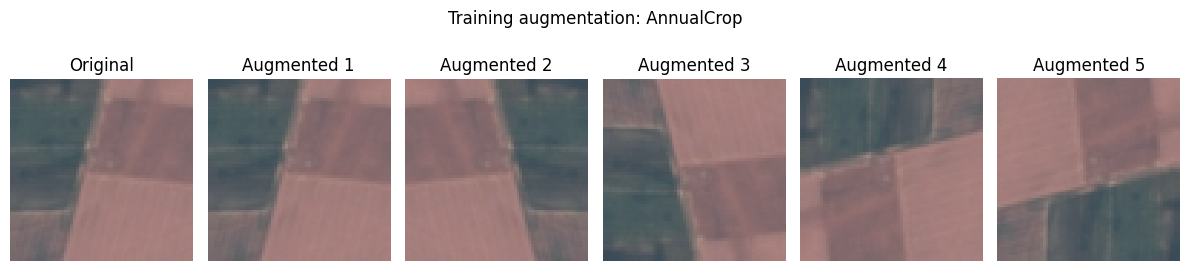

In [11]:
# I use a fixed seed to make this preview reproducible.
random.seed(SEED)
torch.manual_seed(SEED)

# I select an AnnualCrop image from the training set.
preview_row = train_df[train_df["class_name"] == "AnnualCrop"].iloc[0]

with Image.open(preview_row["path"]) as image:
    preview_image = image.convert("RGB")

fig, axes = plt.subplots(1, 6, figsize=(12, 3))

axes[0].imshow(preview_image, interpolation="nearest")
axes[0].set_title("Original")

# I show five independent applications of training augmentation.
for index in range(1, 6):
    augmented_image = train_augmentation(preview_image)
    axes[index].imshow(augmented_image, interpolation="nearest")
    axes[index].set_title(f"Augmented {index}")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"Training augmentation: {preview_row['class_name']}")
plt.tight_layout()
plt.show()

### 5.4 Datasets and data loaders

I create separate datasets for training, validation and testing.
Each sample returns a processed image and its integer class label.

I apply random augmentation only during training. I shuffle training
images and keep validation and test images in a fixed order.

I start with a batch size of 64. I use zero background workers for
compatibility with my Windows notebook.

In [12]:
from torch.utils.data import DataLoader
from cnn_assignment.data import EuroSATSplit

# I set random seeds before creating the loaders.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

train_dataset = EuroSATSplit(train_df, train_transform)
val_dataset = EuroSATSplit(val_df, eval_transform)
test_dataset = EuroSATSplit(test_df, eval_transform)

BATCH_SIZE = 64
pin_memory = device.type == "cuda"

# I use a separate generator to control the training shuffle.
train_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

# I check one training batch without accessing the test images.
images, labels = next(iter(train_loader))

print("Dataset sizes:")
print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nTraining batch:")
print("Image shape:", tuple(images.shape))
print("Label shape:", tuple(labels.shape))
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("All image values finite:", torch.isfinite(images).all().item())

assert images.shape == (BATCH_SIZE, 3, 64, 64)
assert labels.dtype == torch.int64
assert labels.min().item() >= 0
assert labels.max().item() < len(CLASS_NAMES)

Dataset sizes:
Training: 18900
Validation: 4050
Test: 4050

Training batch:
Image shape: (64, 3, 64, 64)
Label shape: (64,)
Image data type: torch.float32
Label data type: torch.int64
All image values finite: True


## 6. Custom CNN models

### 6.1 Model A: Standard CNN

I use three convolution blocks with 32, 64 and 128 output channels.
Each block contains a 3 × 3 convolution, batch normalization, ReLU
and 2 × 2 max-pooling.

I use ReLU because it requires a simple comparison instead of exponentials.
I omit convolution biases because batch normalization follows each convolution.

I use global average pooling to reduce each feature map to one value.
This keeps the final fully connected layer small.

The final layer returns 10 raw scores, called logits, for cross-entropy loss.

In [13]:
import torch.nn as nn
from cnn_assignment.models import StandardCNN

torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

model_a = StandardCNN(num_classes=len(CLASS_NAMES)).to(device)

# I check one batch in evaluation mode without changing batch statistics.
model_a.eval()
with torch.no_grad():
    sample_inputs = images.to(device)
    feature_maps = model_a.features(sample_inputs)
    sample_logits = model_a(sample_inputs)

trainable_params_a = sum(
    parameter.numel()
    for parameter in model_a.parameters()
    if parameter.requires_grad
)

print(model_a)
print("\nFeature map shape:", tuple(feature_maps.shape))
print("Output shape:", tuple(sample_logits.shape))
print(f"Trainable parameters: {trainable_params_a:,}")
print("All output values finite:", torch.isfinite(sample_logits).all().item())

assert sample_logits.shape == (images.shape[0], len(CLASS_NAMES))
assert trainable_params_a == 94762

# I release the temporary GPU tensors after the check.
del sample_inputs, feature_maps, sample_logits

StandardCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (classifier): Linear(in_features=128, out_fea

### 6.2 Model A architecture diagram

I show how one image moves through Model A.
The shapes use the order channels × height × width and exclude the batch
dimension.

Each convolution block includes batch normalization, ReLU and max-pooling.

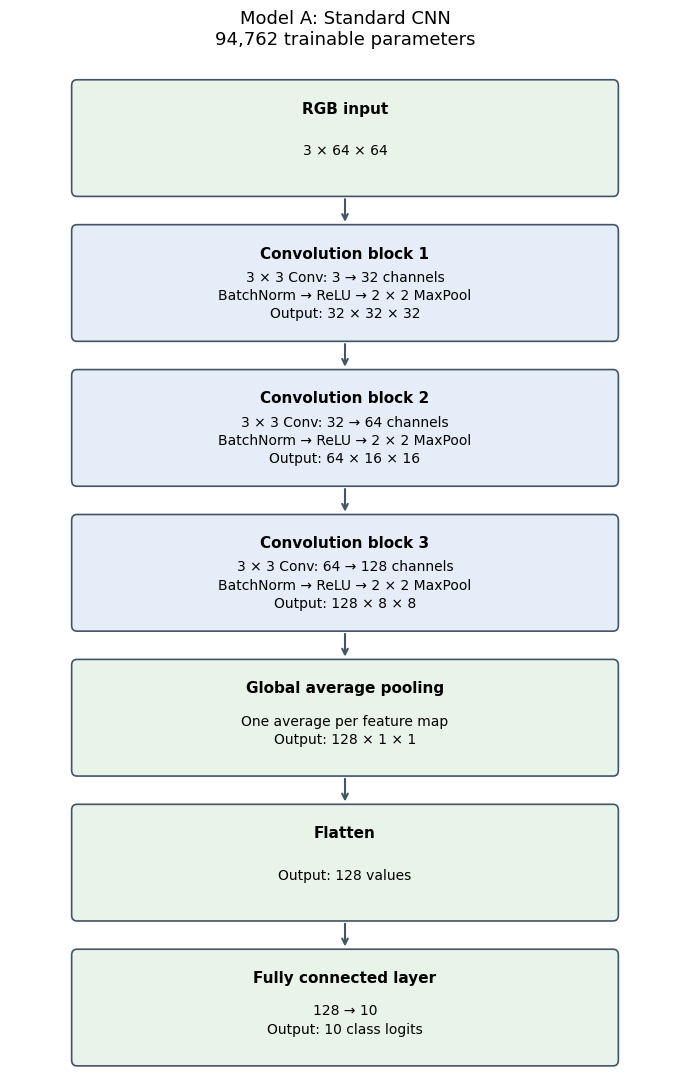

In [14]:
from matplotlib.patches import FancyBboxPatch

# I describe the layers and output shapes of Model A.
stages = [
    ("RGB input", "3 × 64 × 64"),
    (
        "Convolution block 1",
        "3 × 3 Conv: 3 → 32 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 32 × 32 × 32",
    ),
    (
        "Convolution block 2",
        "3 × 3 Conv: 32 → 64 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 64 × 16 × 16",
    ),
    (
        "Convolution block 3",
        "3 × 3 Conv: 64 → 128 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 128 × 8 × 8",
    ),
    (
        "Global average pooling",
        "One average per feature map\nOutput: 128 × 1 × 1",
    ),
    ("Flatten", "Output: 128 values"),
    ("Fully connected layer", "128 → 10\nOutput: 10 class logits"),
]

fig, ax = plt.subplots(figsize=(7, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(stages) * 2)
ax.axis("off")

box_height = 1.45
centres = []

for index, (title, description) in enumerate(stages):
    centre_y = len(stages) * 2 - 1 - index * 2
    centres.append(centre_y)

    colour = "#E5EEF8" if 1 <= index <= 3 else "#E8F3EA"

    box = FancyBboxPatch(
        (1, centre_y - box_height / 2),
        8,
        box_height,
        boxstyle="round,pad=0.08",
        facecolor=colour,
        edgecolor="#425466",
        linewidth=1.2,
    )
    ax.add_patch(box)

    ax.text(
        5, centre_y + 0.40, title,
        ha="center", va="center",
        fontsize=11, fontweight="bold",
    )
    ax.text(
        5, centre_y - 0.18, description,
        ha="center", va="center",
        fontsize=10, linespacing=1.4,
    )

# I connect the blocks in the order used by the forward method.
for upper, lower in zip(centres[:-1], centres[1:]):
    ax.annotate(
        "",
        xy=(5, lower + box_height / 2 + 0.08),
        xytext=(5, upper - box_height / 2 - 0.08),
        arrowprops=dict(
            arrowstyle="->",
            color="#425466",
            linewidth=1.5,
        ),
    )

ax.set_title(
    "Model A: Standard CNN\n94,762 trainable parameters",
    fontsize=13,
    pad=15,
)

plt.tight_layout()
plt.show()

### 6.3 Model B: Lightweight CNN

I replace each standard convolution with a depthwise 3 × 3 convolution
followed by a pointwise 1 × 1 convolution.

The depthwise convolution processes each input channel separately.
The pointwise convolution combines information across channels.

I keep the same output channels, batch normalization, ReLU, max-pooling
and classifier as Model A. This lets me compare the two convolution types
with the other design choices held constant.

I check that Model B has fewer than 100,000 trainable parameters.

In [15]:
from cnn_assignment.models import DepthwiseSeparableBlock, LightweightCNN

torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

model_b = LightweightCNN(num_classes=len(CLASS_NAMES)).to(device)

# I check the output without changing batch normalization statistics.
model_b.eval()
with torch.no_grad():
    sample_inputs = images.to(device)
    feature_maps = model_b.features(sample_inputs)
    sample_logits = model_b(sample_inputs)

trainable_params_b = sum(
    parameter.numel()
    for parameter in model_b.parameters()
    if parameter.requires_grad
)

print(model_b)
print("\nFeature map shape:", tuple(feature_maps.shape))
print("Output shape:", tuple(sample_logits.shape))
print(f"Trainable parameters: {trainable_params_b:,}")
print("All output values finite:", torch.isfinite(sample_logits).all().item())

assert sample_logits.shape == (images.shape[0], len(CLASS_NAMES))
assert trainable_params_b == 12965
assert trainable_params_b <= 100000

print(
    f"Parameter reduction compared with Model A: "
    f"{100 * (1 - trainable_params_b / trainable_params_a):.2f}%"
)

del sample_inputs, feature_maps, sample_logits

LightweightCNN(
  (features): Sequential(
    (0): DepthwiseSeparableBlock(
      (block): Sequential(
        (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=3, bias=False)
        (1): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU(inplace=True)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): DepthwiseSeparableBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU(inplace=True)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): DepthwiseSeparableBlock

### 6.4 Model B architecture diagram

I separate each convolution into two steps. The depthwise convolution
filters each channel independently, and the pointwise convolution
combines channels.

After each pair, I apply batch normalization, ReLU and max-pooling.
The final pooling and classification steps are the same as Model A.

The shapes below use channels × height × width and exclude the batch
dimension.

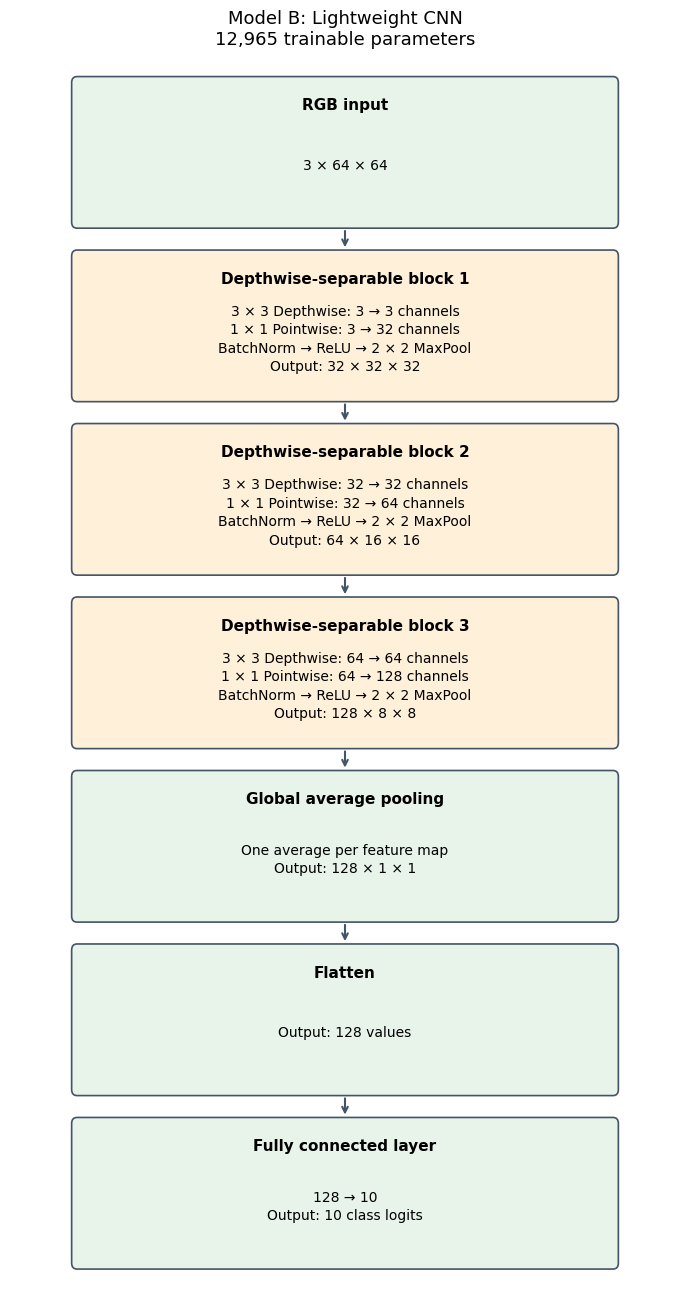

In [16]:
from matplotlib.patches import FancyBboxPatch

# I show the separate depthwise and pointwise steps in each block.
stages_b = [
    ("RGB input", "3 × 64 × 64"),
    (
        "Depthwise-separable block 1",
        "3 × 3 Depthwise: 3 → 3 channels\n"
        "1 × 1 Pointwise: 3 → 32 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 32 × 32 × 32",
    ),
    (
        "Depthwise-separable block 2",
        "3 × 3 Depthwise: 32 → 32 channels\n"
        "1 × 1 Pointwise: 32 → 64 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 64 × 16 × 16",
    ),
    (
        "Depthwise-separable block 3",
        "3 × 3 Depthwise: 64 → 64 channels\n"
        "1 × 1 Pointwise: 64 → 128 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 128 × 8 × 8",
    ),
    (
        "Global average pooling",
        "One average per feature map\nOutput: 128 × 1 × 1",
    ),
    ("Flatten", "Output: 128 values"),
    ("Fully connected layer", "128 → 10\nOutput: 10 class logits"),
]

fig, ax = plt.subplots(figsize=(7, 13))
spacing = 2.3
box_height = 1.85

ax.set_xlim(0, 10)
ax.set_ylim(0, len(stages_b) * spacing)
ax.axis("off")

centres = []

for index, (title, description) in enumerate(stages_b):
    centre_y = len(stages_b) * spacing - spacing / 2 - index * spacing
    centres.append(centre_y)

    colour = "#FFF0DA" if 1 <= index <= 3 else "#E8F3EA"

    box = FancyBboxPatch(
        (1, centre_y - box_height / 2),
        8,
        box_height,
        boxstyle="round,pad=0.08",
        facecolor=colour,
        edgecolor="#425466",
        linewidth=1.2,
    )
    ax.add_patch(box)

    ax.text(
        5, centre_y + 0.62, title,
        ha="center", va="center",
        fontsize=11, fontweight="bold",
    )
    ax.text(
        5, centre_y - 0.18, description,
        ha="center", va="center",
        fontsize=10, linespacing=1.4,
    )

# I connect the blocks in their forward-pass order.
for upper, lower in zip(centres[:-1], centres[1:]):
    ax.annotate(
        "",
        xy=(5, lower + box_height / 2 + 0.08),
        xytext=(5, upper - box_height / 2 - 0.08),
        arrowprops=dict(
            arrowstyle="->",
            color="#425466",
            linewidth=1.5,
        ),
    )

ax.set_title(
    "Model B: Lightweight CNN\n12,965 trainable parameters",
    fontsize=13,
    pad=15,
)

plt.tight_layout()
plt.show()

### 6.5 Parameter and computation comparison

I calculate the trainable parameters of each model, including batch
normalization and the final classifier.

I also estimate multiply-accumulate operations (MACs) for one 64 × 64
image. This estimate includes convolution and linear layers only.

I estimate FP32 parameter storage using four bytes per parameter.
This does not include saved-file overhead, batch normalization buffers
or the memory needed for intermediate feature maps.

In [17]:
# I calculate parameters for each block, including BatchNorm.
parameter_table = pd.DataFrame({
    "stage": ["Block 1", "Block 2", "Block 3", "Classifier"],
    "Model A": [
        3 * 32 * 9 + 2 * 32,
        32 * 64 * 9 + 2 * 64,
        64 * 128 * 9 + 2 * 128,
        128 * 10 + 10,
    ],
    "Model B": [
        3 * 9 + 3 * 32 + 2 * 32,
        32 * 9 + 32 * 64 + 2 * 64,
        64 * 9 + 64 * 128 + 2 * 128,
        128 * 10 + 10,
    ],
})

# I compare my calculations with the actual model parameters.
params_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
params_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)

assert parameter_table["Model A"].sum() == params_a
assert parameter_table["Model B"].sum() == params_b

display(parameter_table)

# I use the feature-map size before each max-pooling step.
macs_a = (
    64**2 * (3 * 32 * 9)
    + 32**2 * (32 * 64 * 9)
    + 16**2 * (64 * 128 * 9)
    + 128 * 10
)

macs_b = (
    64**2 * (3 * 9 + 3 * 32)
    + 32**2 * (32 * 9 + 32 * 64)
    + 16**2 * (64 * 9 + 64 * 128)
    + 128 * 10
)

architecture_comparison = pd.DataFrame({
    "model": ["Model A", "Model B"],
    "trainable_parameters": [params_a, params_b],
    "FP32_parameter_storage_KiB": [
        params_a * 4 / 1024,
        params_b * 4 / 1024,
    ],
    "MACs_per_image": [macs_a, macs_b],
    "MACs_millions": [macs_a / 1e6, macs_b / 1e6],
})

display(architecture_comparison.round(3))

print(f"Parameter reduction: {100 * (1 - params_b / params_a):.2f}%")
print(f"MAC reduction: {100 * (1 - macs_b / macs_a):.2f}%")

,stage,Model A,Model B
0,Block 1,928,187
1,Block 2,18560,2464
2,Block 3,73984,9024
3,Classifier,1290,1290


,model,trainable_parameters,FP32_parameter_storage_KiB,MACs_per_image,MACs_millions
0,Model A,94762,370.164,41288960,41.289
1,Model B,12965,50.645,5141760,5.142


Parameter reduction: 86.32%
MAC reduction: 87.55%


## 7. Training setup

### 7.1 Training and validation functions

I use cross-entropy loss with the raw class scores returned by each model.

During training, I calculate gradients and update the model weights.
During validation, I disable gradient calculation and leave the weights
unchanged.

I calculate average loss and accuracy across all images, including the
smaller final batch. I also record the time taken for each pass.

In [18]:
from cnn_assignment.training import run_epoch as shared_run_epoch

criterion = torch.nn.CrossEntropyLoss()

def run_epoch(model, loader, criterion, optimizer=None):
    # I pass the notebook's selected device explicitly to the shared function.
    return shared_run_epoch(model, loader, criterion, device, optimizer=optimizer)

print("Training and validation functions imported from the package.")
print("Loss function:", criterion)
print("Device:", device)


Training and validation functions imported from the package.
Loss function: CrossEntropyLoss()
Device: cuda


### 7.2 Model checks

I check finite logits and output shapes using the shared architectures.
I retain the old training-step outputs as part of my historical record.
The revised cell performs forward passes without updating weights.


In [19]:
check_results = []
for model_name, model_class in [("Model A", StandardCNN), ("Model B", LightweightCNN)]:
    check_model = model_class(num_classes=len(CLASS_NAMES)).to(device).eval()
    with torch.no_grad():
        check_logits = check_model(images.to(device))
    assert check_logits.shape == (len(images), len(CLASS_NAMES))
    assert torch.isfinite(check_logits).all().item()
    check_results.append({"model": model_name, "output_shape": tuple(check_logits.shape),
                          "outputs_finite": torch.isfinite(check_logits).all().item()})
    del check_model, check_logits
display(pd.DataFrame(check_results))


,model,output_shape,outputs_finite
0,Model A,"(64, 10)",True
1,Model B,"(64, 10)",True


### 7.3 Experiment settings

I compare Adam, SGD and SGD with momentum on both custom models.
I train each configuration for 30 epochs.

I use the same batch size, augmentation and weight decay across runs.
Before each run, I reset the random seeds and create a fresh model.

I start with a learning rate of 0.001 for Adam and 0.01 for both SGD
variants. These are initial settings; I use validation results to decide
whether further learning-rate tuning is needed.

I use momentum 0.9 for SGD with momentum. I save the best model based
on validation loss and keep the full training history.

In [20]:
# Read each experiment's actual saved settings, without constructing models.
experiment_settings = pd.DataFrame([
    {"run": folder.name, "model": config["model"], "optimizer": config["optimizer"],
     "learning_rate": config["optimizer_settings"]["lr"],
     "weight_decay": config["weight_decay"], "epochs": config["epochs"],
     "batch_size": config["batch_size"]}
    for folder in sorted(RUN_DIR.iterdir()) if (folder / "config.json").is_file()
    for config in [load_config(folder / "config.json")]
])
display(experiment_settings)
print("Results folder:", RUN_DIR)
print("I start new runs with the terminal train command in README.md.")


,run,model,optimizer,learning_rate,weight_decay,epochs,batch_size
0,model_a_adam_lr0.001,model_a,adam,0.001,0.0001,30,64
1,model_a_sgd_lr0.003,model_a,sgd,0.003,0.0001,30,64
2,model_a_sgd_lr0.01,model_a,sgd,0.010,0.0001,30,64
3,model_a_sgd_momentum_lr0.01,model_a,sgd_momentum,0.010,0.0001,30,64
4,model_b_adam_lr0.001,model_b,adam,0.001,0.0001,30,64
5,model_b_sgd_lr0.003,model_b,sgd,0.003,0.0001,30,64
6,model_b_sgd_lr0.01,model_b,sgd,0.010,0.0001,30,64
7,model_b_sgd_momentum_lr0.01,model_b,sgd_momentum,0.010,0.0001,30,64
8,model_c_adam_lr0.001,model_c,adam,0.001,0.0001,30,64
9,model_c_sgd_lr0.003,model_c,sgd,0.003,0.0001,30,64


Results folder: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\custom_cnn
I start new runs with the terminal train command in README.md.


### 7.4 Saved experiment reader

I keep training, checkpoint saving and resume logic in the shared package.
I read the six completed histories here to continue my analysis safely.
I use the terminal `train` command with a fresh run name for new experiments.


In [21]:
from cnn_assignment.plotting import load_history

def load_experiment(run_name):
    folder = RUN_DIR / run_name
    config = load_config(folder / "config.json")
    return load_history(folder), config, folder

print("Saved experiment reader ready. The analysis cells also load files directly.")
print("I do not start training in this notebook.")


Saved experiment reader ready. The analysis cells also load files directly.
I do not start training in this notebook.


### 7.5 Model A trained with Adam

I train Model A for 30 epochs using Adam with a learning rate of 0.001
and weight decay of 0.0001.

I monitor training and validation results and save the checkpoint with
the lowest validation loss.

In [22]:
from cnn_assignment.plotting import load_history

run_a_adam = RUN_DIR / "model_a_adam_lr0.001"
config_a_adam = load_config(run_a_adam / "config.json")
history_a_adam = load_history(run_a_adam)
print(f"Reused {len(history_a_adam)} saved epochs: {run_a_adam.name}")


Reused 30 saved epochs: model_a_adam_lr0.001


### 7.6 Model A learning curves

I plot training and validation loss and accuracy across all 30 epochs.

I select epoch 30 because it has the lowest validation loss of 0.1721,
with validation accuracy of 94.12%. The highest validation accuracy
was 94.72% at epoch 22.

Training accuracy is measured with random augmentation, while validation
accuracy is measured without augmentation. I consider this difference
when comparing the curves.

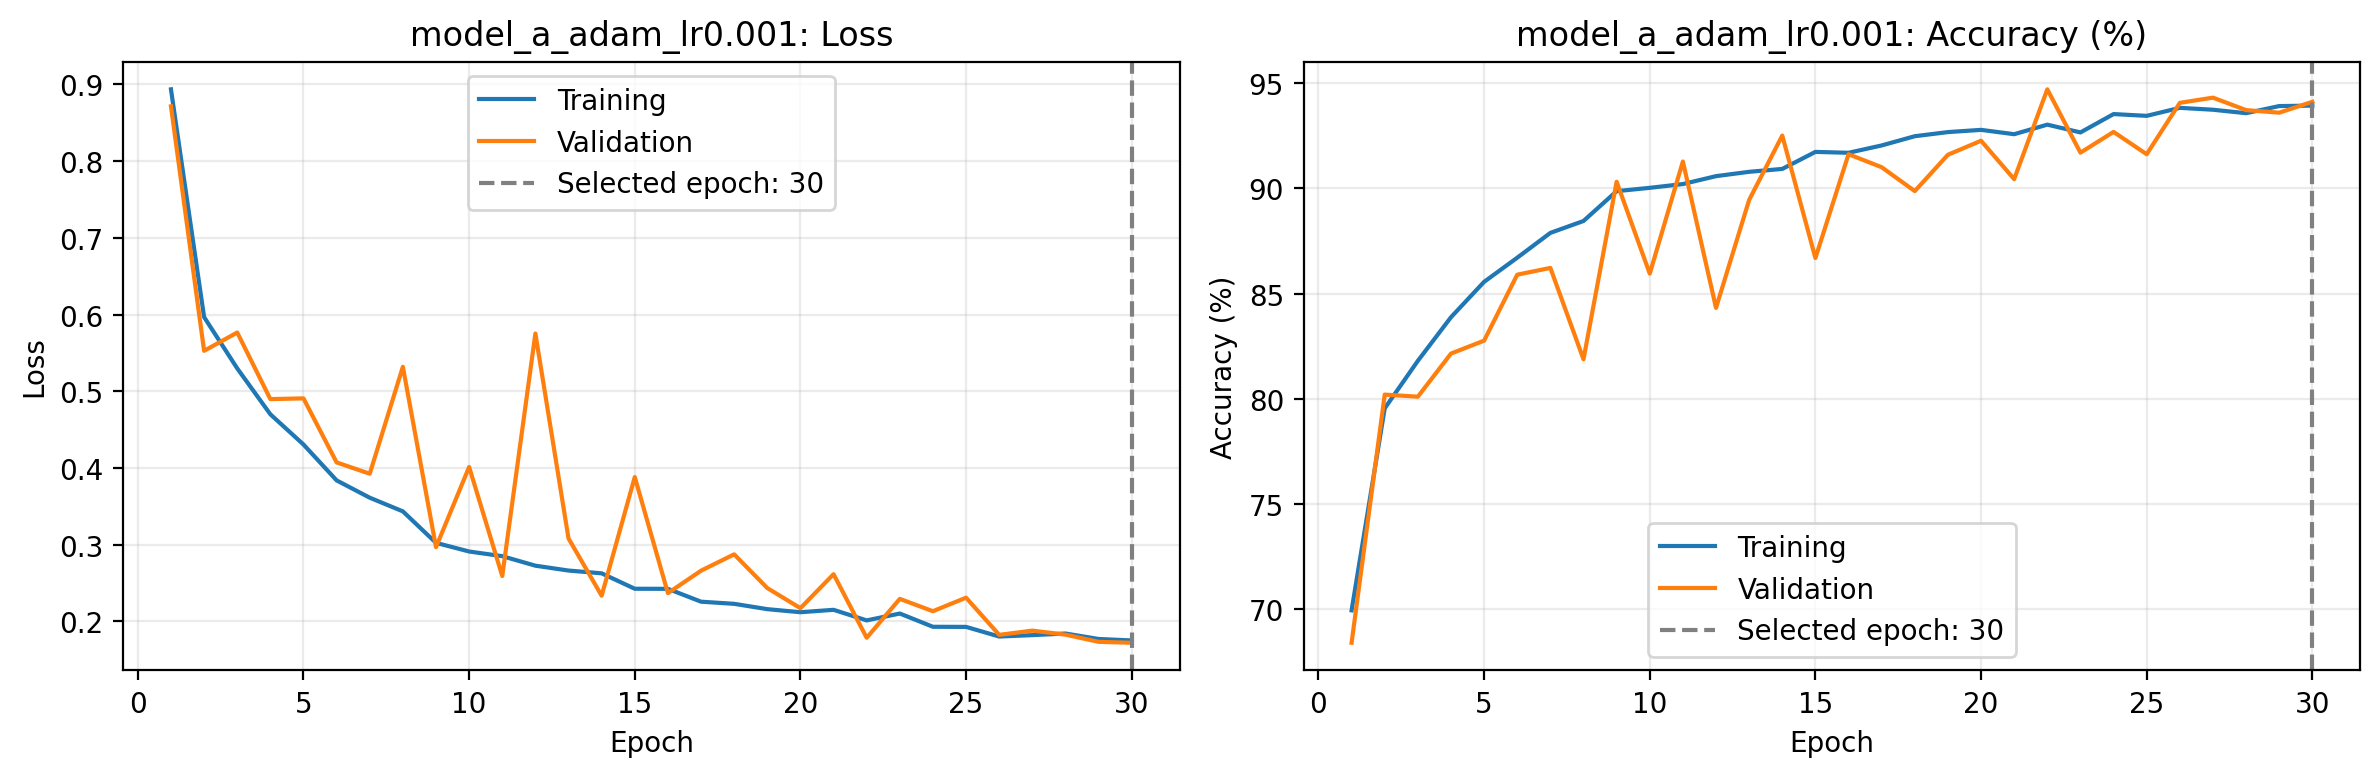

,run_folder,model,optimizer,learning_rate,selected_epoch,selected_val_loss,selected_val_accuracy_percent,mean_train_seconds,mean_train_seconds_excluding_first
0,model_a_adam_lr0.001,model_a,adam,0.001,30,0.17211,94.123457,26.776831,25.266525


Plot saved: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\reports\notebook_model_a_adam_lr0.001_xv270lte\learning_curves.png


In [23]:
from cnn_assignment.plotting import plot_history
from IPython.display import Image as DisplayImage

# This cell needs only the first setup cell, not the experiment reader.
run_a_adam = RUN_DIR / "model_a_adam_lr0.001"
plot_path = new_notebook_report("model_a_adam_lr0.001") / "learning_curves.png"
summary = plot_history(run_a_adam, plot_path)
display(DisplayImage(filename=str(plot_path)))
display(pd.DataFrame([summary]))
print("Plot saved:", plot_path)


### 7.7 Model B trained with Adam

I train Model B for 30 epochs using the same Adam learning rate of 0.001,
weight decay of 0.0001 and batch size of 64 as Model A.

I use the same dataset splits, preprocessing and augmentation.
I select the checkpoint with the lowest validation loss and compare
its performance and training time with Model A.

In [24]:
from cnn_assignment.plotting import load_history

run_b_adam = RUN_DIR / "model_b_adam_lr0.001"
config_b_adam = load_config(run_b_adam / "config.json")
history_b_adam = load_history(run_b_adam)
print(f"Reused {len(history_b_adam)} saved epochs: {run_b_adam.name}")


Reused 30 saved epochs: model_b_adam_lr0.001


### 7.8 Model B learning curves

I plot training and validation loss and accuracy for Model B across
all 30 epochs.

I select epoch 27 because it has the lowest validation loss of 0.2445,
with validation accuracy of 91.56%.

Training uses random augmentation, while validation does not.

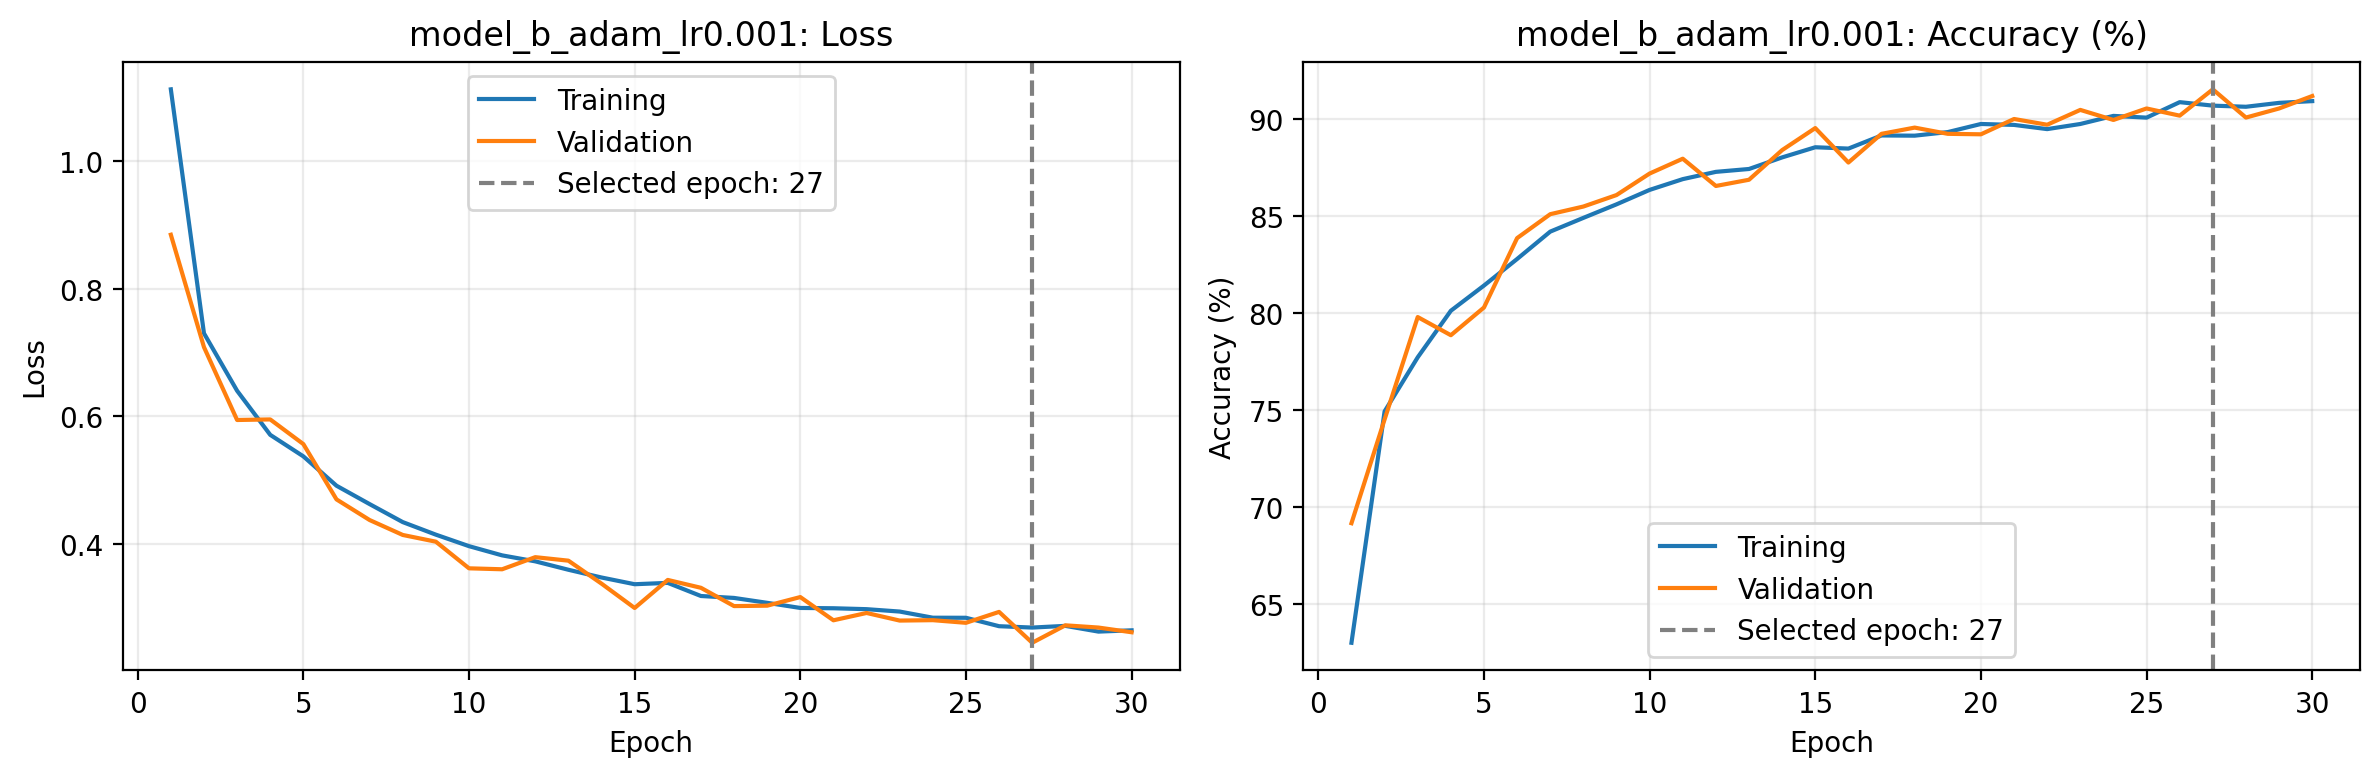

,run_folder,model,optimizer,learning_rate,selected_epoch,selected_val_loss,selected_val_accuracy_percent,mean_train_seconds,mean_train_seconds_excluding_first
0,model_b_adam_lr0.001,model_b,adam,0.001,27,0.244486,91.555556,27.785076,24.949462


Plot saved: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\reports\notebook_model_b_adam_lr0.001_f398kv5d\learning_curves.png


In [25]:
from cnn_assignment.plotting import plot_history
from IPython.display import Image as DisplayImage

# This cell needs only the first setup cell, not the experiment reader.
run_b_adam = RUN_DIR / "model_b_adam_lr0.001"
plot_path = new_notebook_report("model_b_adam_lr0.001") / "learning_curves.png"
summary = plot_history(run_b_adam, plot_path)
display(DisplayImage(filename=str(plot_path)))
display(pd.DataFrame([summary]))
print("Plot saved:", plot_path)


### 7.9 Comparing the custom models with Adam

Model B shows a steadier validation-loss trend in this run, but Model A
achieves a lower validation loss and higher validation accuracy.

At the checkpoints selected by validation loss, Model A reaches 94.12%
validation accuracy and Model B reaches 91.56%.

Model B uses substantially fewer parameters and MACs. However, their
average training times after the first epoch are similar on my laptop.

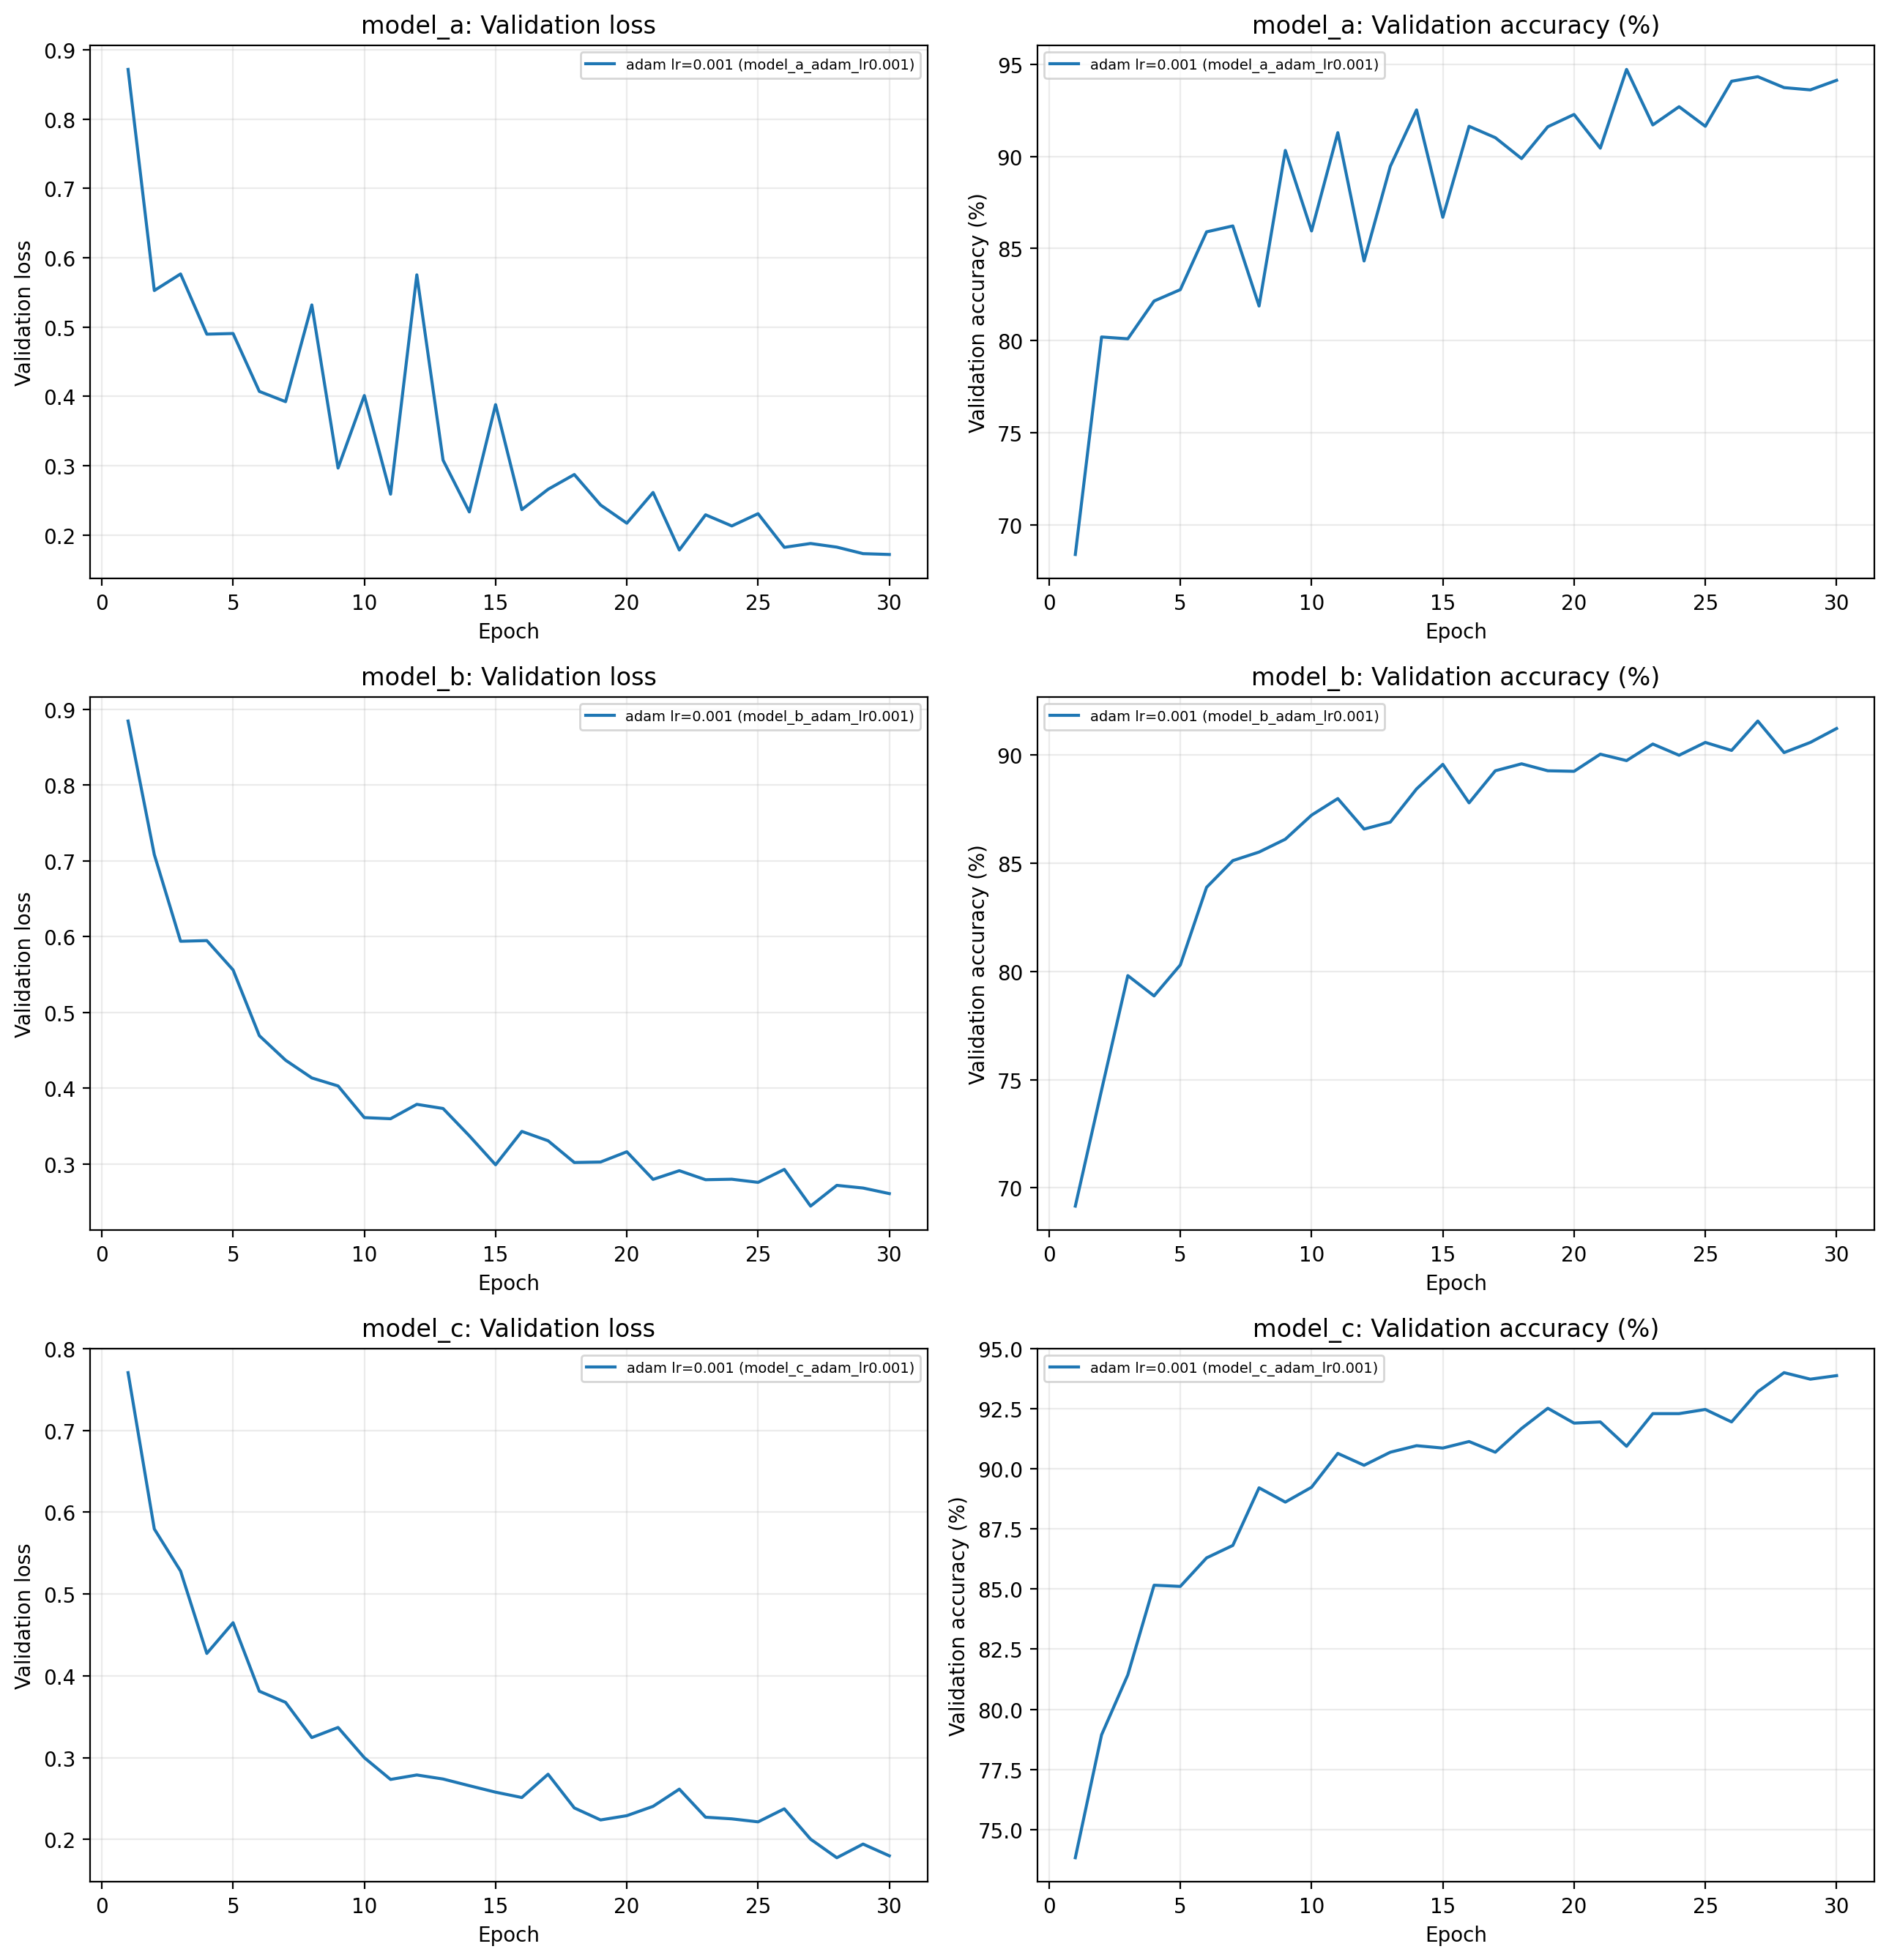

,run_folder,model,optimizer,learning_rate,selected_epoch,selected_val_loss,selected_val_accuracy_percent,mean_train_seconds,mean_train_seconds_excluding_first
0,model_a_adam_lr0.001,model_a,adam,0.001,30,0.172110,94.123457,26.776831,25.266525
1,model_b_adam_lr0.001,model_b,adam,0.001,27,0.244486,91.555556,27.785076,24.949462
2,model_c_adam_lr0.001,model_c,adam,0.001,28,0.177609,94.000000,30.532371,25.623895


Comparison saved: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\reports\notebook_adam_comparison_m48rb5pq


In [26]:
from cnn_assignment.plotting import plot_comparison
from IPython.display import Image as DisplayImage

comparison_runs = [folder for folder in sorted(RUN_DIR.iterdir())
                   if folder.is_dir() and (folder / "history.csv").is_file() and (folder / "config.json").is_file() and load_config(folder / "config.json")["optimizer"] == "adam"]
comparison_output = new_notebook_report("adam_comparison")
comparison_rows = plot_comparison(comparison_runs, comparison_output)
display(DisplayImage(filename=str(comparison_output / "optimizer_comparison.png")))
display(pd.DataFrame(comparison_rows))

print("Comparison saved:", comparison_output)


### 7.10 Model A trained with SGD

I train Model A for 30 epochs using SGD with a learning rate of 0.01
and no momentum.

I keep the same weight decay, batch size, augmentation and dataset splits.
I reset the random seeds and start with fresh model weights.

I use validation results to compare this initial SGD setting with Adam.

In [27]:
from cnn_assignment.plotting import load_history

run_a_sgd = RUN_DIR / "model_a_sgd_lr0.01"
config_a_sgd = load_config(run_a_sgd / "config.json")
history_a_sgd = load_history(run_a_sgd)
print(f"Reused {len(history_a_sgd)} saved epochs: {run_a_sgd.name}")


Reused 30 saved epochs: model_a_sgd_lr0.01


### 7.11 Model A learning curves with SGD

Training loss decreases steadily, but validation loss and accuracy
fluctuate considerably.

I select epoch 27 because it has the lowest validation loss of 0.3796,
with validation accuracy of 87.21%.

This initial SGD configuration performs worse than my Adam configuration.
I will compare momentum and consider further learning-rate tuning before
drawing a final conclusion about the optimizers.

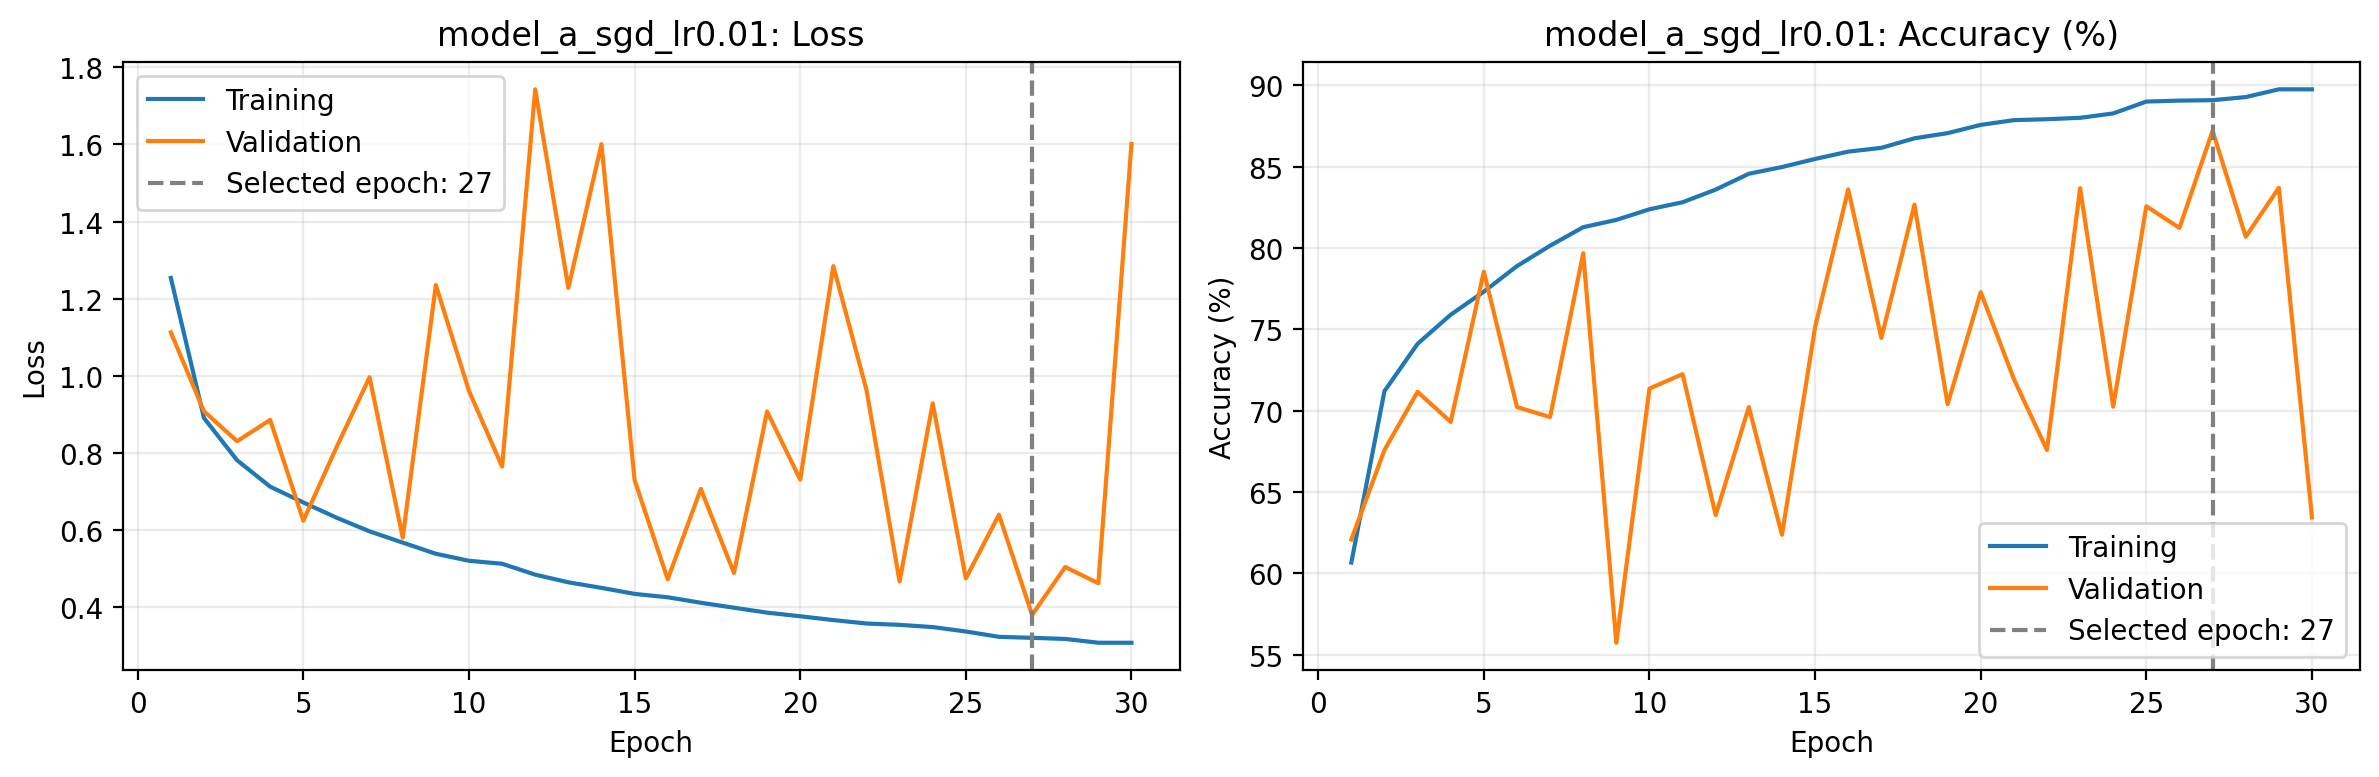

,run_folder,model,optimizer,learning_rate,selected_epoch,selected_val_loss,selected_val_accuracy_percent,mean_train_seconds,mean_train_seconds_excluding_first
0,model_a_sgd_lr0.01,model_a,sgd,0.01,27,0.379596,87.209877,26.005598,26.032462


Plot saved: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\reports\notebook_model_a_sgd_lr0.01_n5fkuxqx\learning_curves.png


In [28]:
from cnn_assignment.plotting import plot_history
from IPython.display import Image as DisplayImage

# This cell needs only the first setup cell, not the experiment reader.
run_a_sgd = RUN_DIR / "model_a_sgd_lr0.01"
plot_path = new_notebook_report("model_a_sgd_lr0.01") / "learning_curves.png"
summary = plot_history(run_a_sgd, plot_path)
display(DisplayImage(filename=str(plot_path)))
display(pd.DataFrame([summary]))
print("Plot saved:", plot_path)


### 7.12 Saved checkpoint check

I reload Model A's selected SGD checkpoint using the shared evaluation module.
I evaluate it on validation images and compare loss and accuracy with the saved
minimum-loss epoch. The original outputs below record my earlier two-pass check.
I do not update weights or evaluate the test set.


In [29]:
from cnn_assignment.evaluation import evaluate

# Load the architecture, validation split, normalization and checkpoint directly.
# Only the first setup cell is required; no loaders or training cells are needed.
validation_output = new_notebook_report("validation") / "validation_check"
validation_check = evaluate(
    PROJECT_ROOT, RUN_DIR / "model_a_sgd_lr0.01", split="validation",
    data_root=DATA_ROOT, split_dir=SPLIT_DIR, num_workers=0,
    compare_history=True, output_dir=validation_output,
)
display(pd.DataFrame([validation_check["history_comparison"]]))
print("Validation matches saved history:", validation_check["history_comparison"]["matches"])
print("Validation report:", validation_output)


Validation:   0%|          | 0/64 [00:00<?, ?it/s]

,selected_epoch,saved_val_loss,saved_val_accuracy,loss_difference,loss_matches,accuracy_matches,matches,loss_rtol,loss_atol,accuracy_atol
0,27,0.379596,0.872099,0.0,True,True,True,0.00001,0.000001,1.000000e-08


Validation matches saved history: True
Validation report: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\reports\notebook_validation_ob3ux03i\validation_check


### 7.13 Model A trained with SGD and momentum

I train Model A using SGD with learning rate 0.01 and momentum 0.9.
I keep the other settings unchanged from the standard SGD run.

Momentum carries information from previous gradients into the next update.
I compare the learning curves to see how this changes convergence and
validation performance.

In [30]:
from cnn_assignment.plotting import load_history

run_a_momentum = RUN_DIR / "model_a_sgd_momentum_lr0.01"
config_a_momentum = load_config(run_a_momentum / "config.json")
history_a_momentum = load_history(run_a_momentum)
print(f"Reused {len(history_a_momentum)} saved epochs: {run_a_momentum.name}")


Reused 30 saved epochs: model_a_sgd_momentum_lr0.01


### 7.14 Model A learning curves with SGD and momentum

I select epoch 30, which has validation loss 0.1745 and validation
accuracy 94.20%.

At the same learning rate, adding momentum improves convergence and
selected validation accuracy compared with standard SGD. Validation
still fluctuates during training.

Adam and momentum SGD achieve similar final validation performance
in these runs.

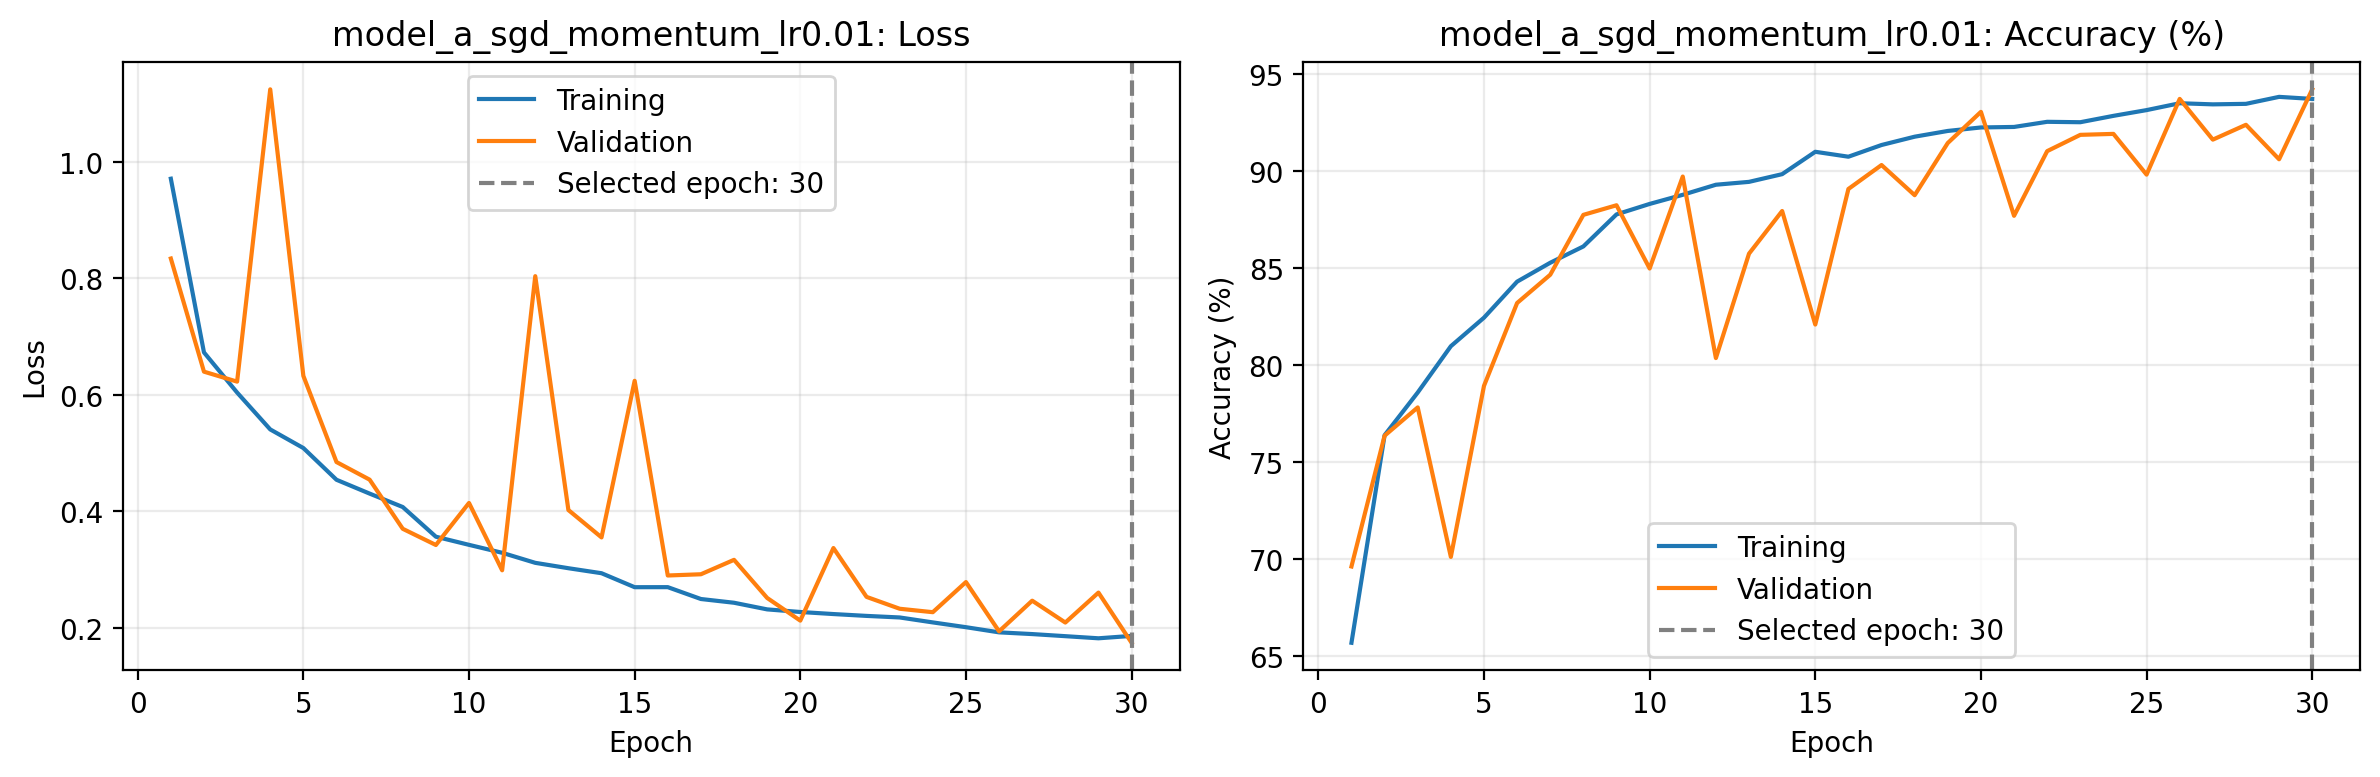

,run_folder,model,optimizer,learning_rate,selected_epoch,selected_val_loss,selected_val_accuracy_percent,mean_train_seconds,mean_train_seconds_excluding_first
0,model_a_sgd_momentum_lr0.01,model_a,sgd_momentum,0.01,30,0.174506,94.197531,23.936241,23.952597


Plot saved: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\reports\notebook_model_a_sgd_momentum_lr0.01_snsqfwps\learning_curves.png


In [31]:
from cnn_assignment.plotting import plot_history
from IPython.display import Image as DisplayImage

# This cell needs only the first setup cell, not the experiment reader.
run_a_momentum = RUN_DIR / "model_a_sgd_momentum_lr0.01"
plot_path = new_notebook_report("model_a_sgd_momentum_lr0.01") / "learning_curves.png"
summary = plot_history(run_a_momentum, plot_path)
display(DisplayImage(filename=str(plot_path)))
display(pd.DataFrame([summary]))
print("Plot saved:", plot_path)


### 7.15 Model B trained with SGD

I train Model B for 30 epochs using SGD with learning rate 0.01
and no momentum.

I keep the same weight decay, batch size, augmentation and dataset splits.
I compare this run with Model B trained using Adam.

In [32]:
from cnn_assignment.plotting import load_history

run_b_sgd = RUN_DIR / "model_b_sgd_lr0.01"
config_b_sgd = load_config(run_b_sgd / "config.json")
history_b_sgd = load_history(run_b_sgd)
print(f"Reused {len(history_b_sgd)} saved epochs: {run_b_sgd.name}")


Reused 30 saved epochs: model_b_sgd_lr0.01


### 7.16 Model B learning curves with SGD

I select epoch 28 because it has the lowest validation loss of 0.4831,
with validation accuracy of 83.53%.

Training loss continues to decrease across the 30 epochs, while validation
results fluctuate. At these initial settings, SGD learns more slowly
and achieves lower selected validation accuracy than Adam.

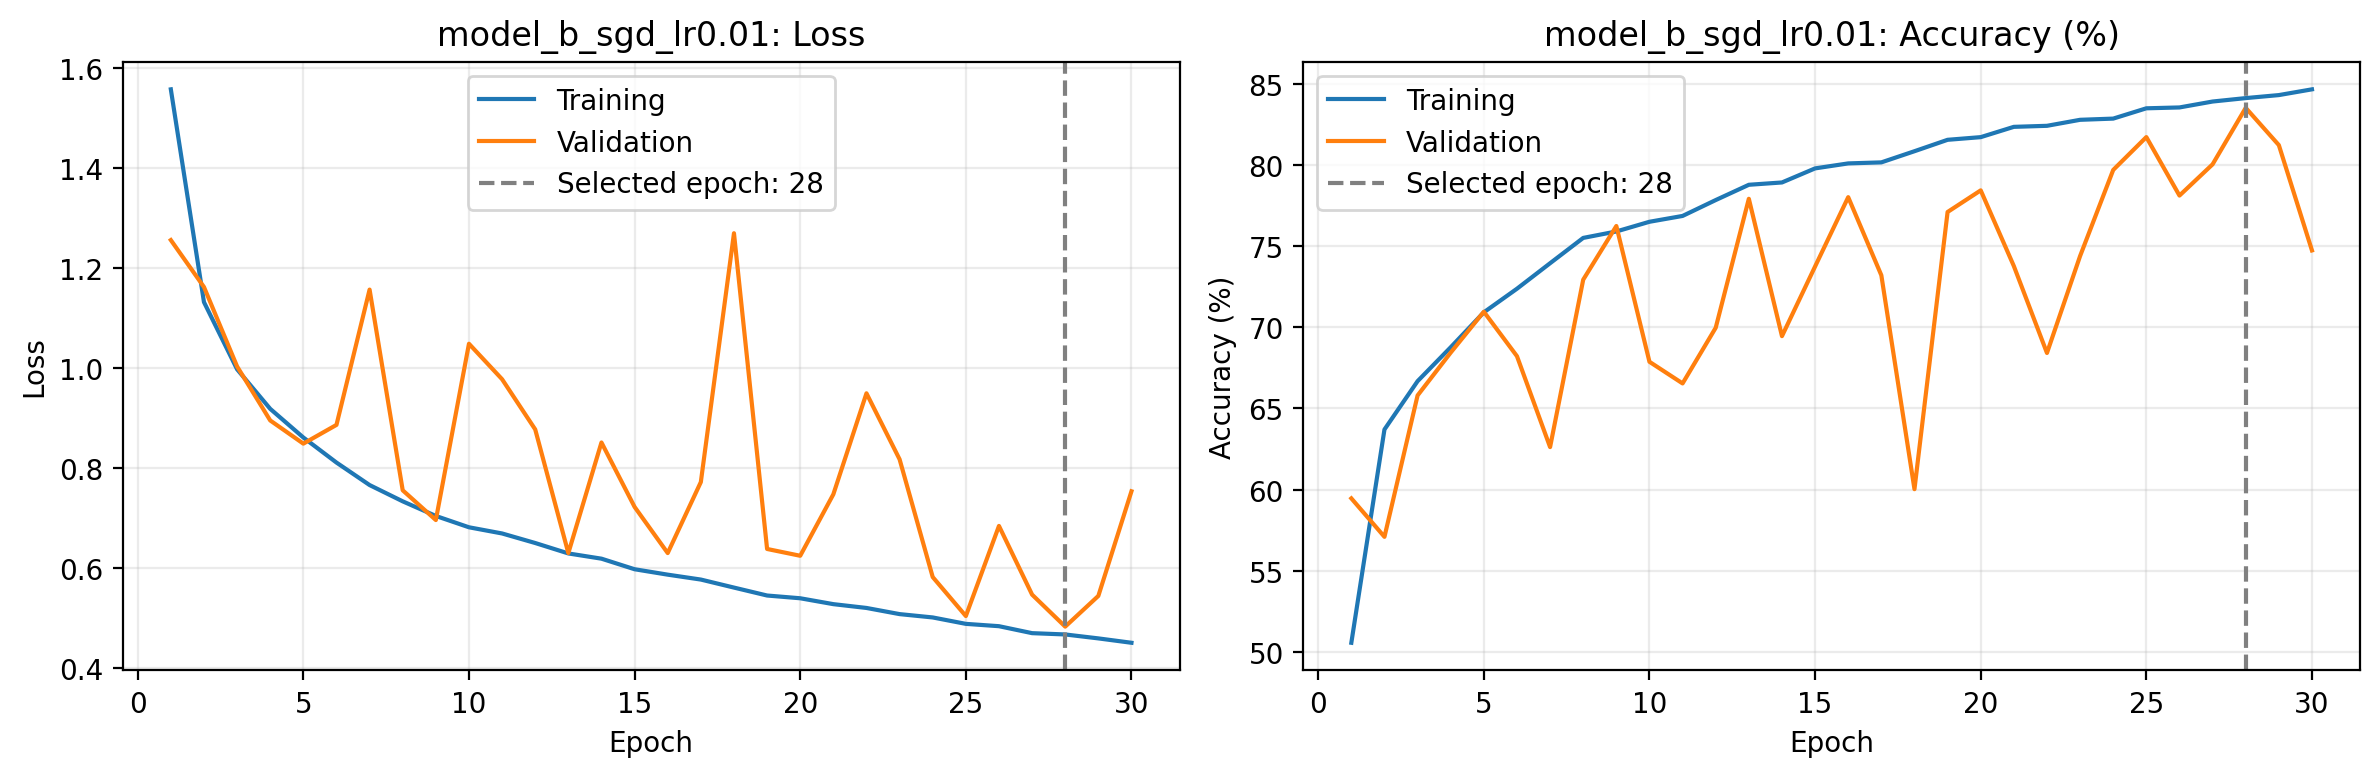

,run_folder,model,optimizer,learning_rate,selected_epoch,selected_val_loss,selected_val_accuracy_percent,mean_train_seconds,mean_train_seconds_excluding_first
0,model_b_sgd_lr0.01,model_b,sgd,0.01,28,0.483142,83.530864,25.385775,25.460869


Plot saved: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\reports\notebook_model_b_sgd_lr0.01_mm34wuz3\learning_curves.png


In [33]:
from cnn_assignment.plotting import plot_history
from IPython.display import Image as DisplayImage

# This cell needs only the first setup cell, not the experiment reader.
run_b_sgd = RUN_DIR / "model_b_sgd_lr0.01"
plot_path = new_notebook_report("model_b_sgd_lr0.01") / "learning_curves.png"
summary = plot_history(run_b_sgd, plot_path)
display(DisplayImage(filename=str(plot_path)))
display(pd.DataFrame([summary]))
print("Plot saved:", plot_path)


### 7.17 Model B trained with SGD and momentum

I train Model B for 30 epochs using SGD with learning rate 0.01
and momentum 0.9.

I keep the other settings unchanged from the standard SGD run.
I compare the results to see whether momentum improves convergence
and validation performance.

In [34]:
from cnn_assignment.plotting import load_history

run_b_momentum = RUN_DIR / "model_b_sgd_momentum_lr0.01"
config_b_momentum = load_config(run_b_momentum / "config.json")
history_b_momentum = load_history(run_b_momentum)
print(f"Reused {len(history_b_momentum)} saved epochs: {run_b_momentum.name}")


Reused 30 saved epochs: model_b_sgd_momentum_lr0.01


### 7.18 Model B learning curves with SGD and momentum

I select epoch 25 because it has the lowest validation loss of 0.2347,
with validation accuracy of 91.83%.

Adding momentum improves convergence and selected validation performance
compared with plain SGD at the same learning rate.

The selected result is slightly better than Adam's in this run, although
validation performance still fluctuates.

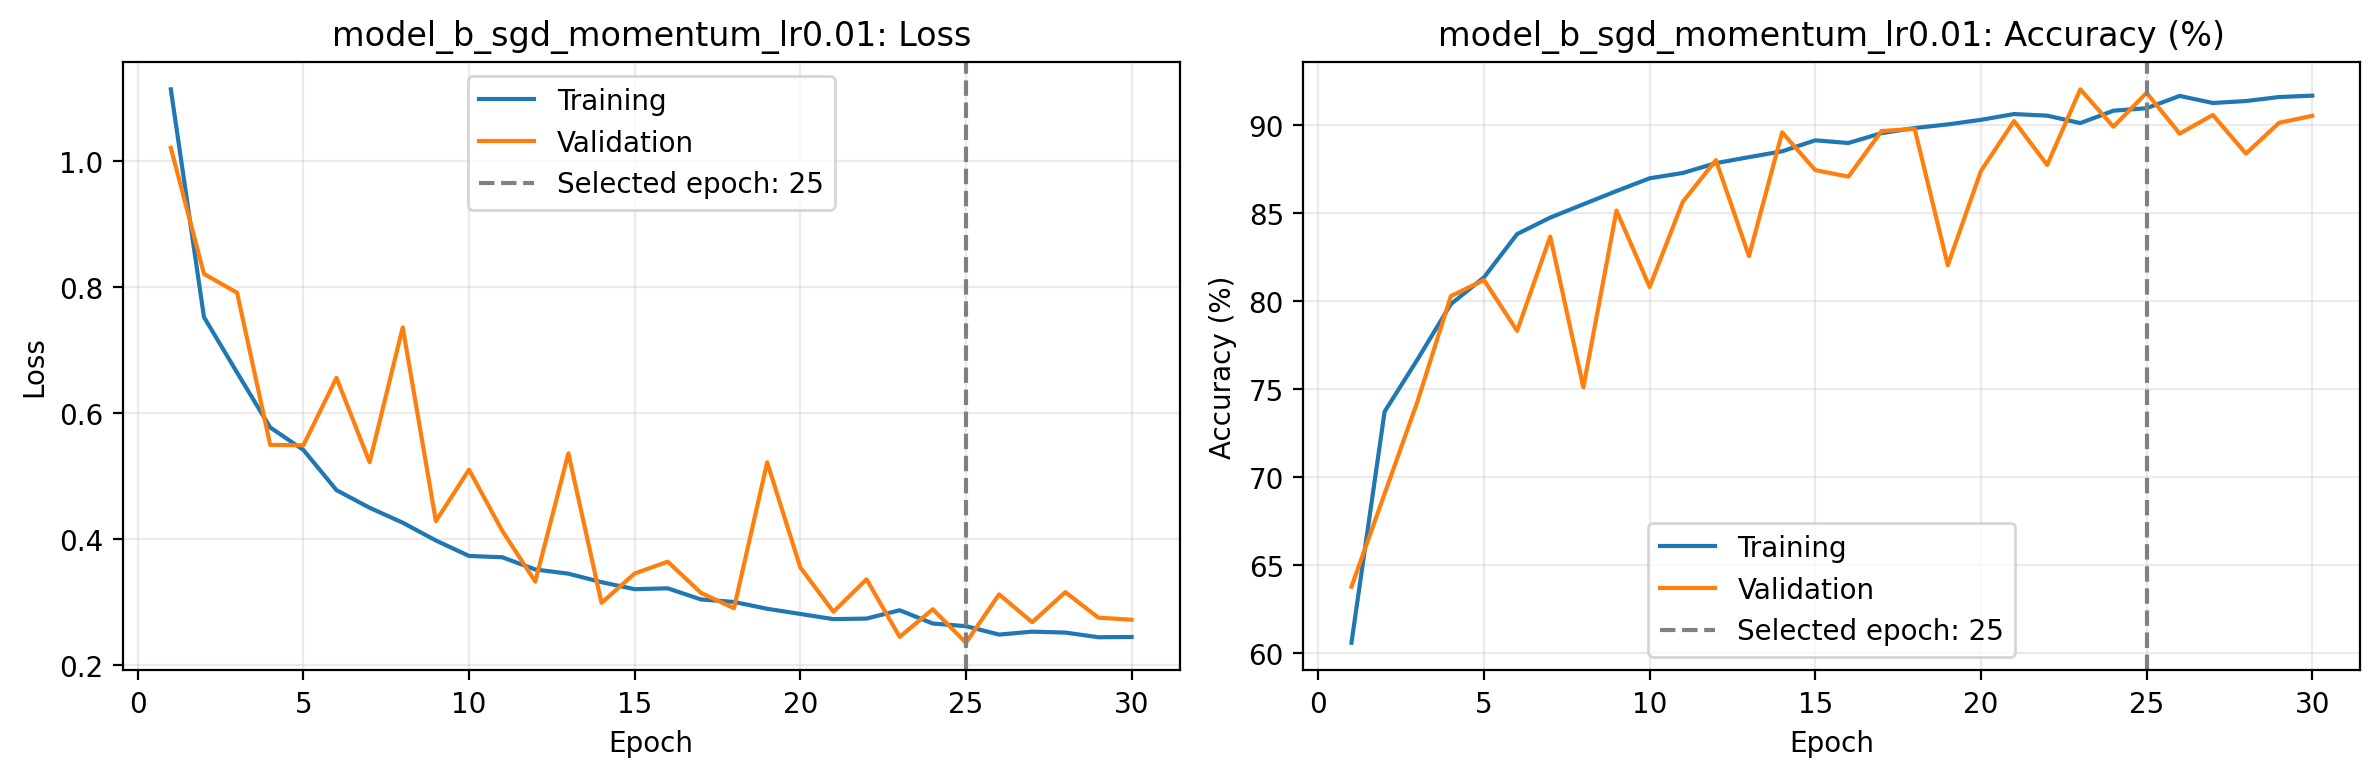

,run_folder,model,optimizer,learning_rate,selected_epoch,selected_val_loss,selected_val_accuracy_percent,mean_train_seconds,mean_train_seconds_excluding_first
0,model_b_sgd_momentum_lr0.01,model_b,sgd_momentum,0.01,25,0.234703,91.82716,26.102649,26.212977


Plot saved: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\reports\notebook_model_b_sgd_momentum_lr0.01_kt5kzih3\learning_curves.png


In [35]:
from cnn_assignment.plotting import plot_history
from IPython.display import Image as DisplayImage

# This cell needs only the first setup cell, not the experiment reader.
run_b_momentum = RUN_DIR / "model_b_sgd_momentum_lr0.01"
plot_path = new_notebook_report("model_b_sgd_momentum_lr0.01") / "learning_curves.png"
summary = plot_history(run_b_momentum, plot_path)
display(DisplayImage(filename=str(plot_path)))
display(pd.DataFrame([summary]))
print("Plot saved:", plot_path)


### 7.19 Optimizer comparison

I compare Adam, SGD and SGD with momentum for both custom models.
Each run uses 30 epochs, the same data splits and the same regularization.

I report validation accuracy at the checkpoint selected by minimum
validation loss. I also compare the loss curves and training times.

These results describe the learning rates I tested. They do not show
the best possible performance of every optimizer.

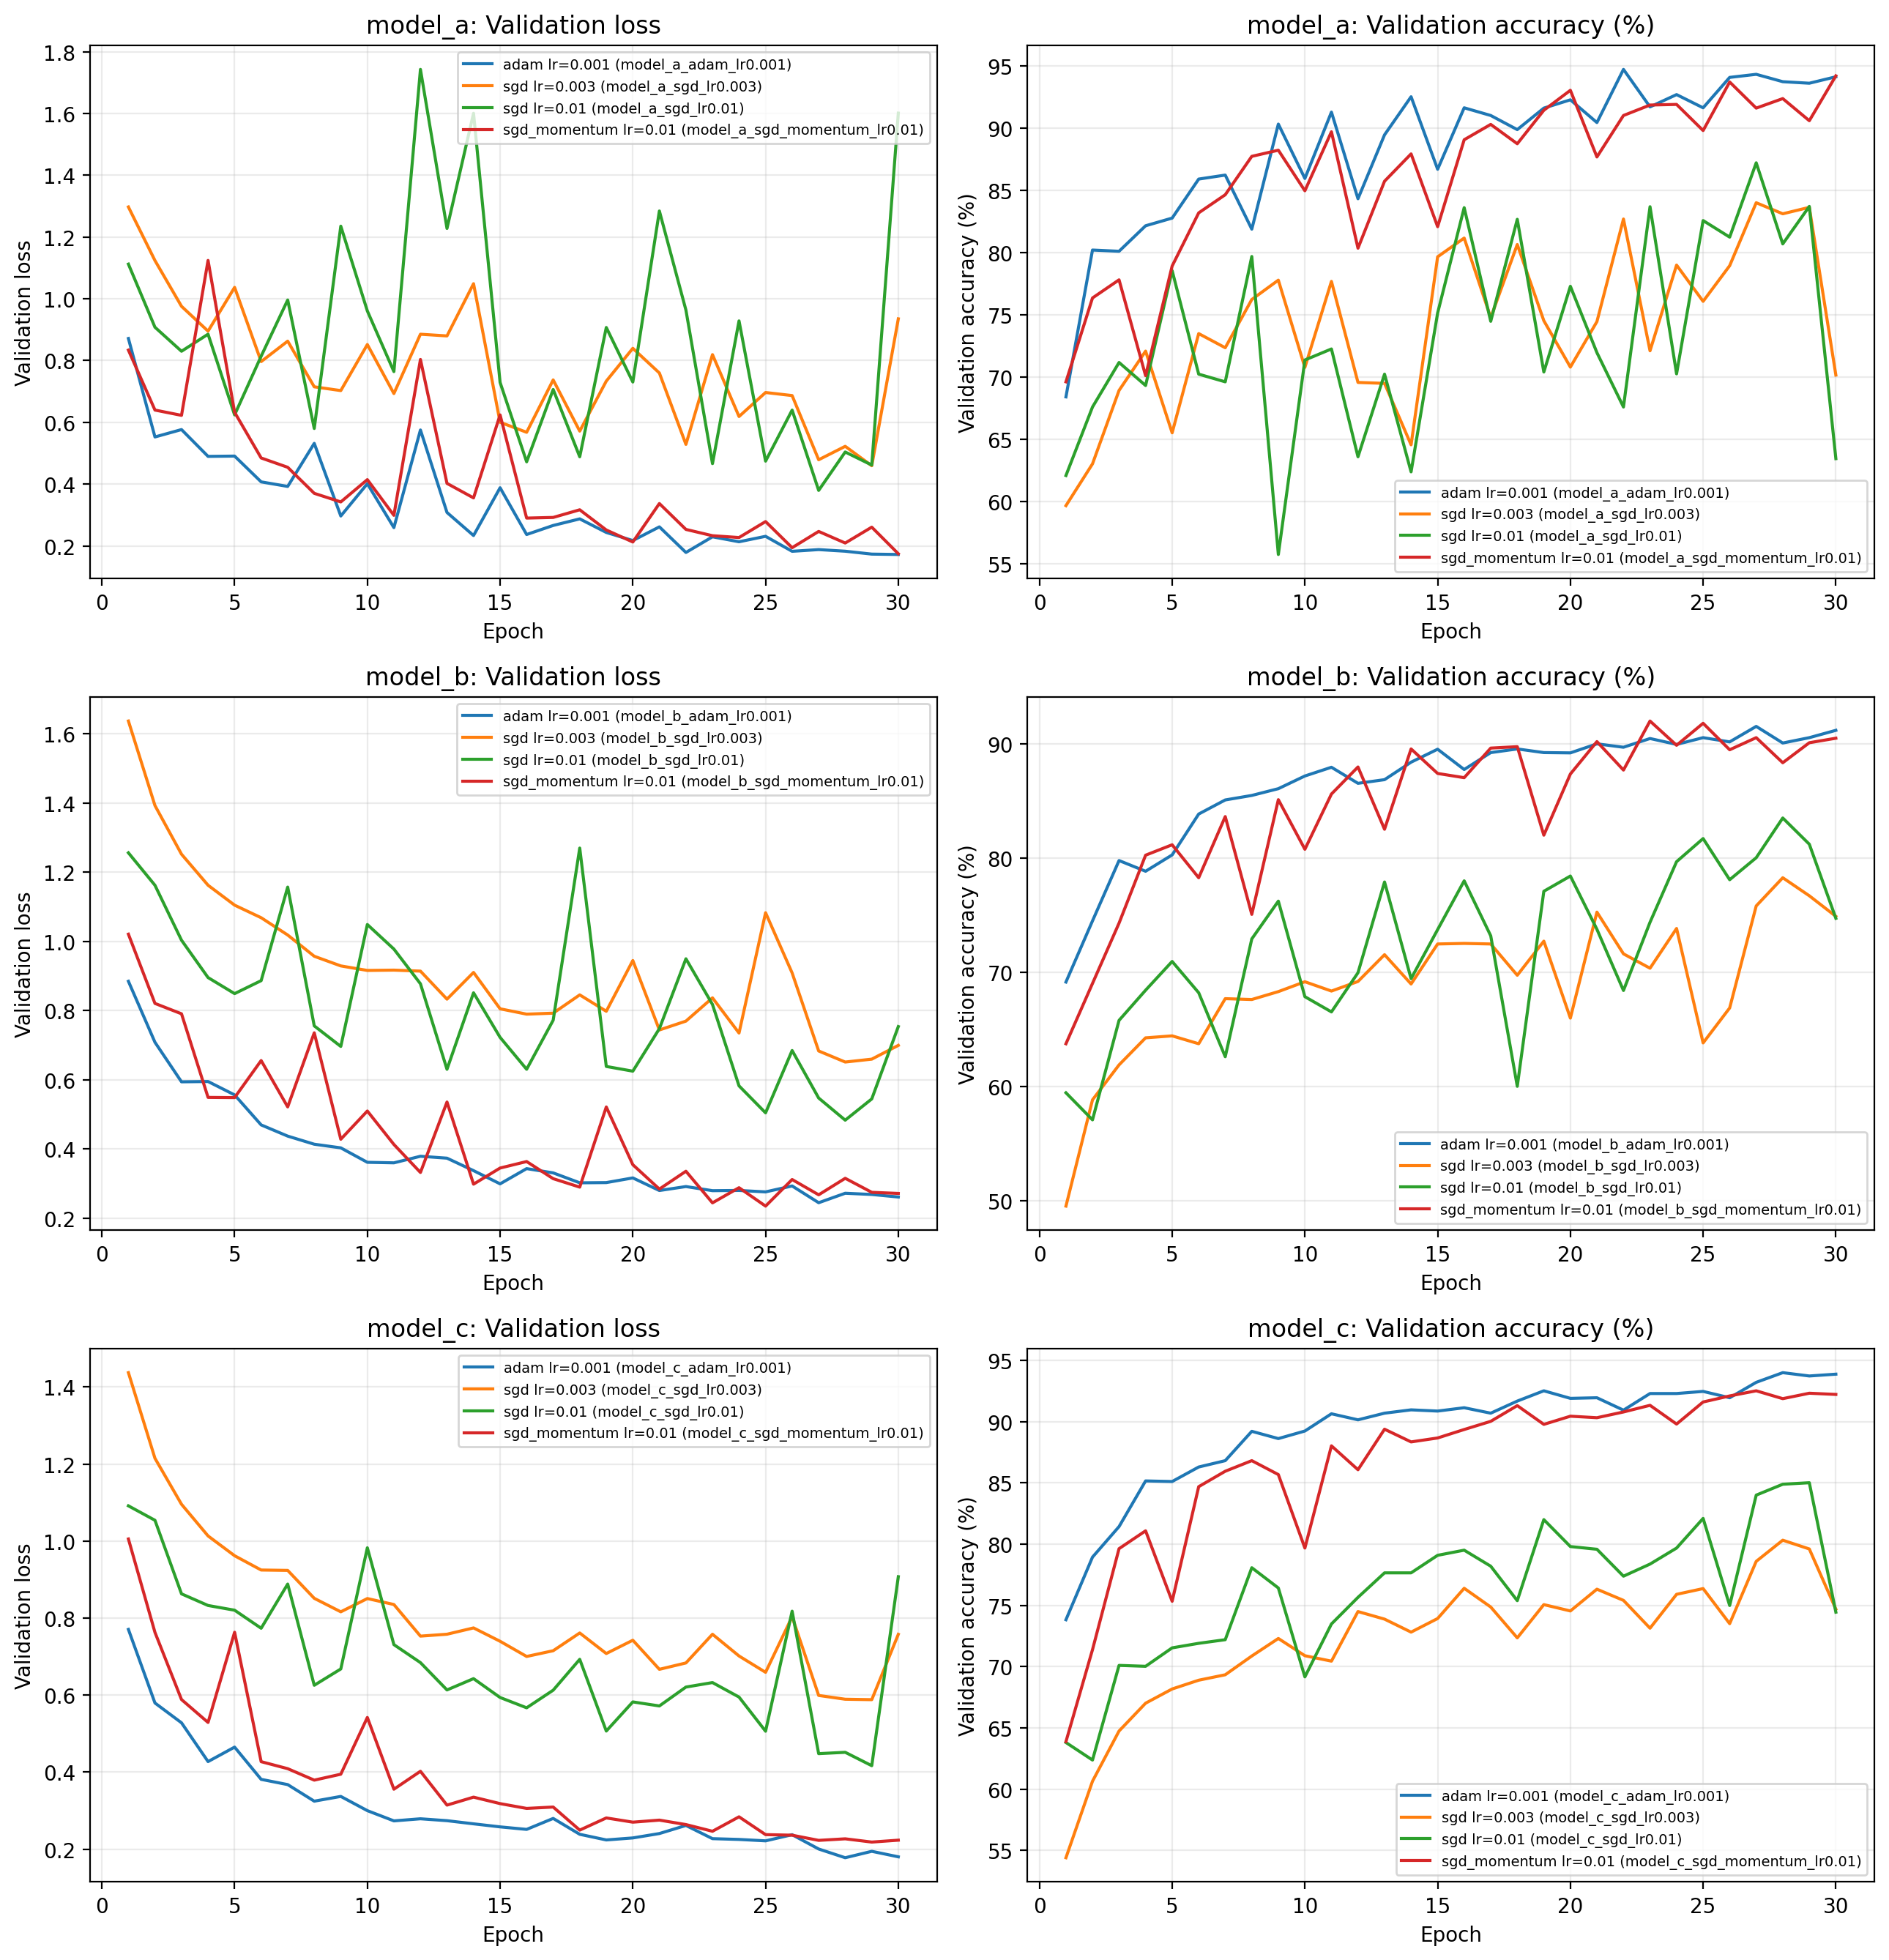

,run_folder,model,optimizer,learning_rate,selected_epoch,selected_val_loss,selected_val_accuracy_percent,mean_train_seconds,mean_train_seconds_excluding_first
0,model_a_adam_lr0.001,model_a,adam,0.001,30,0.172110,94.123457,26.776831,25.266525
1,model_a_sgd_lr0.003,model_a,sgd,0.003,29,0.459452,83.629630,28.104214,24.185852
2,model_a_sgd_lr0.01,model_a,sgd,0.010,27,0.379596,87.209877,26.005598,26.032462
3,model_a_sgd_momentum_lr0.01,model_a,sgd_momentum,0.010,30,0.174506,94.197531,23.936241,23.952597
4,model_b_adam_lr0.001,model_b,adam,0.001,27,0.244486,91.555556,27.785076,24.949462
5,model_b_sgd_lr0.003,model_b,sgd,0.003,28,0.651173,78.296296,27.930627,23.396881
6,model_b_sgd_lr0.01,model_b,sgd,0.010,28,0.483142,83.530864,25.385775,25.460869
7,model_b_sgd_momentum_lr0.01,model_b,sgd_momentum,0.010,25,0.234703,91.827160,26.102649,26.212977
8,model_c_adam_lr0.001,model_c,adam,0.001,28,0.177609,94.000000,30.532371,25.623895
9,model_c_sgd_lr0.003,model_c,sgd,0.003,29,0.588112,79.604938,24.334127,24.399791


Comparison saved: D:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\outputs\reports\notebook_optimizer_comparison_hsiifks2


In [36]:
from cnn_assignment.plotting import plot_comparison
from IPython.display import Image as DisplayImage

comparison_runs = [folder for folder in sorted(RUN_DIR.iterdir())
                   if folder.is_dir() and (folder / "history.csv").is_file() and (folder / "config.json").is_file()]
comparison_output = new_notebook_report("optimizer_comparison")
comparison_rows = plot_comparison(comparison_runs, comparison_output)
display(DisplayImage(filename=str(comparison_output / "optimizer_comparison.png")))
display(pd.DataFrame(comparison_rows))

print("Comparison saved:", comparison_output)


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# I reconnect to my saved experiment results after restarting.
RUN_DIR = PROJECT_ROOT / "outputs" / "custom_cnn"

for folder in sorted(RUN_DIR.iterdir()):
    if folder.is_dir():
        history_path = folder / "history.csv"
        weights_path = folder / "best_weights.pt"

        if history_path.is_file():
            history = pd.read_csv(history_path)
            print(
                f"{folder.name}: {len(history)} epochs saved | "
                f"checkpoint exists: {weights_path.is_file()}"
            )

model_a_adam_lr0.001: 30 epochs saved | checkpoint exists: True
model_a_sgd_lr0.003: 30 epochs saved | checkpoint exists: True
model_a_sgd_lr0.01: 30 epochs saved | checkpoint exists: True
model_a_sgd_momentum_lr0.01: 30 epochs saved | checkpoint exists: True
model_b_adam_lr0.001: 30 epochs saved | checkpoint exists: True
model_b_sgd_lr0.003: 30 epochs saved | checkpoint exists: True
model_b_sgd_lr0.01: 30 epochs saved | checkpoint exists: True
model_b_sgd_momentum_lr0.01: 30 epochs saved | checkpoint exists: True
model_c_adam_lr0.001: 30 epochs saved | checkpoint exists: True
model_c_sgd_lr0.003: 30 epochs saved | checkpoint exists: True
model_c_sgd_lr0.01: 30 epochs saved | checkpoint exists: True
model_c_sgd_momentum_lr0.01: 30 epochs saved | checkpoint exists: True


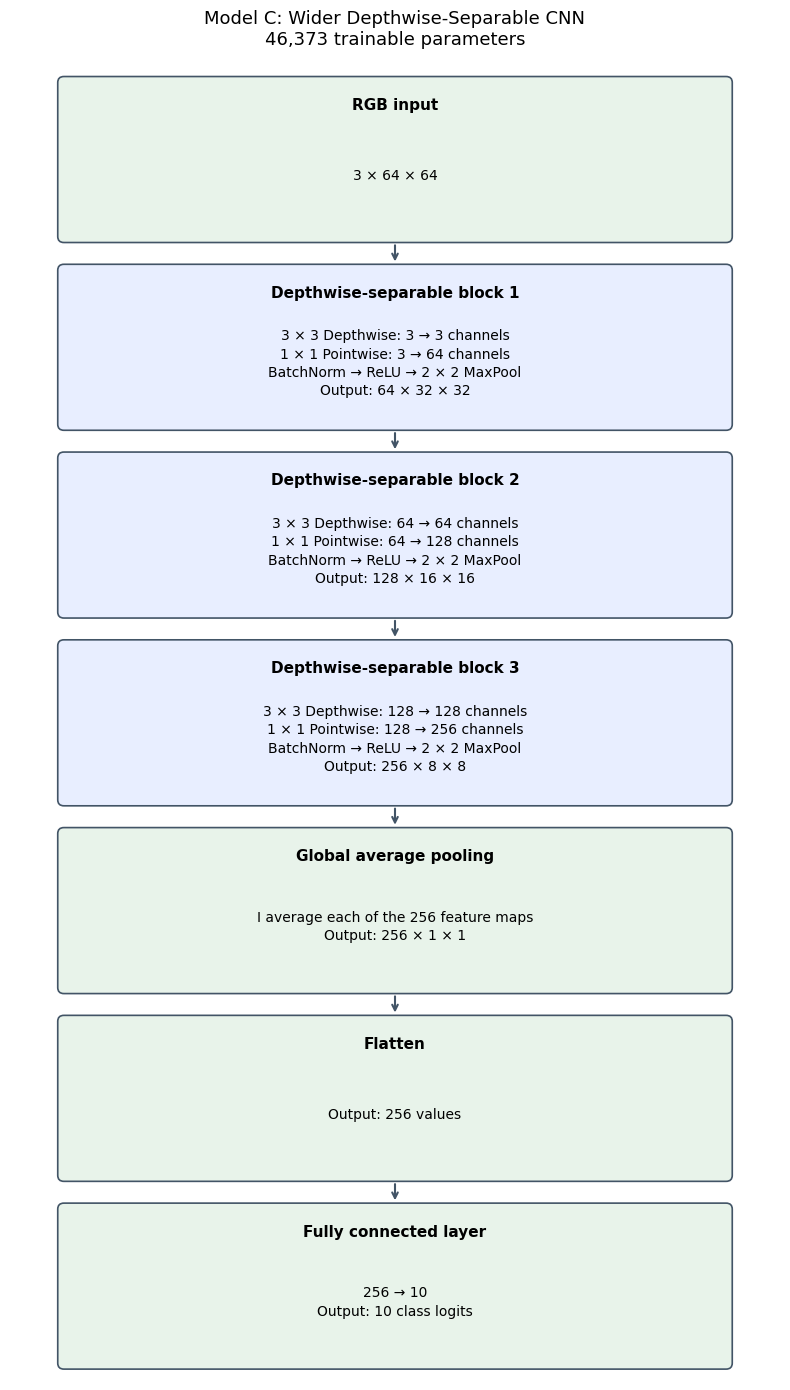

In [39]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# I show how Model C uses more channels than Model B.
stages_c = [
    ("RGB input", "3 × 64 × 64"),
    (
        "Depthwise-separable block 1",
        "3 × 3 Depthwise: 3 → 3 channels\n"
        "1 × 1 Pointwise: 3 → 64 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 64 × 32 × 32",
    ),
    (
        "Depthwise-separable block 2",
        "3 × 3 Depthwise: 64 → 64 channels\n"
        "1 × 1 Pointwise: 64 → 128 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 128 × 16 × 16",
    ),
    (
        "Depthwise-separable block 3",
        "3 × 3 Depthwise: 128 → 128 channels\n"
        "1 × 1 Pointwise: 128 → 256 channels\n"
        "BatchNorm → ReLU → 2 × 2 MaxPool\n"
        "Output: 256 × 8 × 8",
    ),
    (
        "Global average pooling",
        "I average each of the 256 feature maps\n"
        "Output: 256 × 1 × 1",
    ),
    ("Flatten", "Output: 256 values"),
    ("Fully connected layer", "256 → 10\nOutput: 10 class logits"),
]

fig, ax = plt.subplots(figsize=(8, 14))
spacing = 2.5
box_height = 2.05

ax.set_xlim(0, 10)
ax.set_ylim(0, len(stages_c) * spacing)
ax.axis("off")

centres = []

for index, (title, description) in enumerate(stages_c):
    centre_y = len(stages_c) * spacing - spacing / 2 - index * spacing
    centres.append(centre_y)

    colour = "#E8EEFF" if 1 <= index <= 3 else "#E8F3EA"

    box = FancyBboxPatch(
        (0.7, centre_y - box_height / 2),
        8.6,
        box_height,
        boxstyle="round,pad=0.08",
        facecolor=colour,
        edgecolor="#425466",
        linewidth=1.2,
    )
    ax.add_patch(box)

    ax.text(
        5, centre_y + 0.72, title,
        ha="center", va="center",
        fontsize=11, fontweight="bold",
    )
    ax.text(
        5, centre_y - 0.22, description,
        ha="center", va="center",
        fontsize=10, linespacing=1.4,
    )

# I connect the stages in the order used during prediction.
for upper, lower in zip(centres[:-1], centres[1:]):
    ax.annotate(
        "",
        xy=(5, lower + box_height / 2 + 0.08),
        xytext=(5, upper - box_height / 2 - 0.08),
        arrowprops=dict(
            arrowstyle="->",
            color="#425466",
            linewidth=1.5,
        ),
    )

ax.set_title(
    "Model C: Wider Depthwise-Separable CNN\n"
    "46,373 trainable parameters",
    fontsize=13,
    pad=15,
)

plt.tight_layout()
plt.show()